### Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Directly search for 46_53-32-cube

In [75]:
from pathlib import Path

root = Path("/content/drive/MyDrive")
matches = list(root.rglob("46_53-32_cube"))

print("Found:", len(matches))
for m in matches[:20]:
    print(m)

Found: 1
/content/drive/MyDrive/rectified_flow_ct2dose/data/raw/46_53-32_cube


### (1)Import dependencies and create image directory

In [2]:
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, Subset

FIG_ROOT = Path("/content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures")
(FIG_ROOT / "regression_128").mkdir(parents=True, exist_ok=True)
(FIG_ROOT / "flow_unet_128").mkdir(parents=True, exist_ok=True)

print("Figure root:", FIG_ROOT)

Figure root: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures


### Set paths

In [4]:
from pathlib import Path

DATA_ROOT = Path("/content/drive/MyDrive/rectified_flow_ct2dose/data/raw/46_53-32_cube/output")
SAVE_DIR = Path("/content/drive/MyDrive/rectified_flow_ct2dose/outputs/inspect_one_pair")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT exists:", DATA_ROOT.exists())
print("SAVE_DIR:", SAVE_DIR)

DATA_ROOT exists: True
SAVE_DIR: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/inspect_one_pair


### Continue running directory checks

In [5]:
case_dirs = sorted([p for p in DATA_ROOT.iterdir() if p.is_dir()])

print("Number of case folders:", len(case_dirs))
print("First 5 case folders:")
for p in case_dirs[:5]:
    print(" -", p.name)

Number of case folders: 10
First 5 case folders:
 - 132102389758881090179672567372987664560
 - 156339165372145091992366212553627308160
 - 169178663511657097619787299759624979616
 - 226808136684964871480153898846429021344
 - 235101017859661465075472232303048949736


### Run a check on a pair of cubes

In [6]:
import numpy as np

case_dir = case_dirs[0]
input_dir = case_dir / "input_cubes"
output_dir = case_dir / "output_cubes"

input_files = sorted(input_dir.glob("*.npy"))
output_files = sorted(output_dir.glob("*.npy"))

print("Case folder:", case_dir.name)
print("Number of input cubes :", len(input_files))
print("Number of output cubes:", len(output_files))

input_path = input_files[0]
output_path = output_dir / input_path.name

print("\nInput file :", input_path.name)
print("Output file:", output_path.name)
print("Output exists:", output_path.exists())

x0 = np.load(input_path)
x1 = np.load(output_path)

print("\n=== Input cube stats ===")
print("shape:", x0.shape)
print("dtype:", x0.dtype)
print("min:", x0.min())
print("max:", x0.max())
print("mean:", x0.mean())
print("std:", x0.std())

print("\n=== Output cube stats ===")
print("shape:", x1.shape)
print("dtype:", x1.dtype)
print("min:", x1.min())
print("max:", x1.max())
print("mean:", x1.mean())
print("std:", x1.std())

print("\nSame shape:", x0.shape == x1.shape)

Case folder: 132102389758881090179672567372987664560
Number of input cubes : 2000
Number of output cubes: 2000

Input file : 132102389758881090179672567372987664560_0.npy
Output file: 132102389758881090179672567372987664560_0.npy
Output exists: True

=== Input cube stats ===
shape: (32, 32, 32)
dtype: float32
min: -1015.4789
max: 1178.9115
mean: -492.20496
std: 452.35004

=== Output cube stats ===
shape: (32, 32, 32)
dtype: float64
min: 7.880194282166008e-07
max: 0.0027264456622491727
mean: 4.694996166212774e-05
std: 6.340797396523633e-05

Same shape: True


### Plot the middle slice

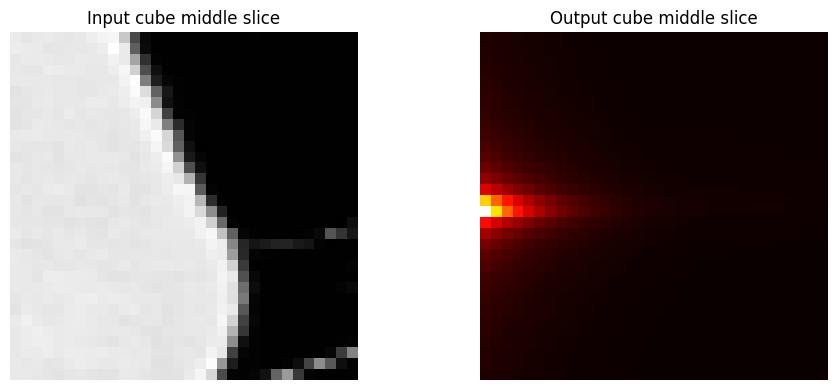

In [7]:
import matplotlib.pyplot as plt

mid = x0.shape[0] // 2

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(x0[mid], cmap="gray")
axes[0].set_title("Input cube middle slice")
axes[0].axis("off")

axes[1].imshow(x1[mid], cmap="hot")
axes[1].set_title("Output cube middle slice")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Find the extra input file

In [8]:
from pathlib import Path

case_dir = case_dirs[0]
input_dir = case_dir / "input_cubes"
output_dir = case_dir / "output_cubes"

input_names = sorted([p.name for p in input_dir.glob("*.npy")])
output_names = sorted([p.name for p in output_dir.glob("*.npy")])

input_set = set(input_names)
output_set = set(output_names)

only_input = sorted(input_set - output_set)
only_output = sorted(output_set - input_set)

print("Only in input:", len(only_input))
for x in only_input[:20]:
    print("  ", x)

print("\nOnly in output:", len(only_output))
for x in only_output[:20]:
    print("  ", x)

Only in input: 0

Only in output: 0


### Do not take the middle slice first, change it to the "slice with the strongest dose"

Best slice index: 16


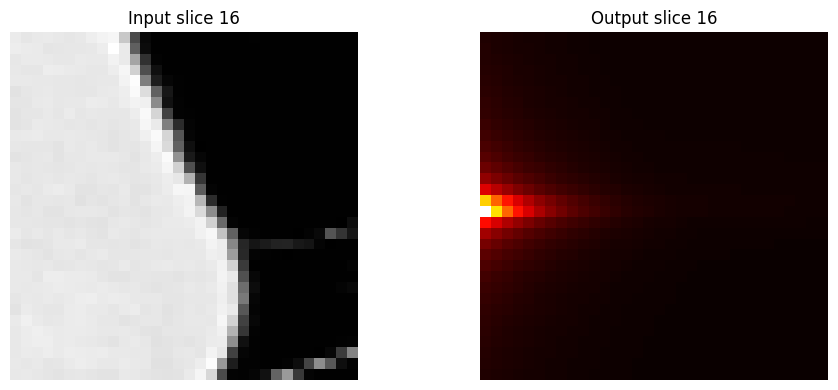

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# x0: input cube, x1: output cube
scores = x1.sum(axis=(1, 2))   # 每个 z-slice 的总 dose
best_idx = int(np.argmax(scores))

print("Best slice index:", best_idx)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(x0[best_idx], cmap="gray")
axes[0].set_title(f"Input slice {best_idx}")
axes[0].axis("off")

axes[1].imshow(x1[best_idx], cmap="hot")
axes[1].set_title(f"Output slice {best_idx}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Quickly reconfirm that the number of files in this case are aligned

In [10]:
from pathlib import Path

case_dir = case_dirs[0]
input_dir = case_dir / "input_cubes"
output_dir = case_dir / "output_cubes"

input_files = sorted(input_dir.glob("*.npy"))
output_files = sorted(output_dir.glob("*.npy"))

print("Number of input cubes :", len(input_files))
print("Number of output cubes:", len(output_files))
print("Same count:", len(input_files) == len(output_files))

Number of input cubes : 2000
Number of output cubes: 2000
Same count: True


### 0. Build a 2D manifest using fixed slice 16

In [11]:
import json
from pathlib import Path

DATA_ROOT = Path("/content/drive/MyDrive/rectified_flow_ct2dose/data/raw/46_53-32_cube/output")
SPLIT_DIR = Path("/content/drive/MyDrive/rectified_flow_ct2dose/data/splits")
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

case_dirs = sorted([p for p in DATA_ROOT.iterdir() if p.is_dir()])

train_case_dirs = case_dirs[:8]
test_case_dirs = case_dirs[8:]

print("Train cases:", len(train_case_dirs))
print("Test cases :", len(test_case_dirs))


def build_2d_manifest_fixed_slice(case_dirs, slice_index=16):
    records = []

    for case_dir in case_dirs:
        input_dir = case_dir / "input_cubes"
        output_dir = case_dir / "output_cubes"

        input_files = sorted(input_dir.glob("*.npy"))

        for input_path in input_files:
            output_path = output_dir / input_path.name
            if not output_path.exists():
                continue

            records.append({
                "case_id": case_dir.name,
                "input_path": str(input_path),
                "output_path": str(output_path),
                "slice_index": slice_index
            })

    return records


train_records = build_2d_manifest_fixed_slice(train_case_dirs, slice_index=16)
test_records = build_2d_manifest_fixed_slice(test_case_dirs, slice_index=16)

print("Train samples:", len(train_records))
print("Test samples :", len(test_records))

with open(SPLIT_DIR / "train_pairs_2d.json", "w", encoding="utf-8") as f:
    json.dump(train_records, f, indent=2)

with open(SPLIT_DIR / "test_pairs_2d.json", "w", encoding="utf-8") as f:
    json.dump(test_records, f, indent=2)

print("Saved:")
print(SPLIT_DIR / "train_pairs_2d.json")
print(SPLIT_DIR / "test_pairs_2d.json")

Train cases: 8
Test cases : 2
Train samples: 16000
Test samples : 4000
Saved:
/content/drive/MyDrive/rectified_flow_ct2dose/data/splits/train_pairs_2d.json
/content/drive/MyDrive/rectified_flow_ct2dose/data/splits/test_pairs_2d.json


### 1.Define CubeSlice2DDataset

In [3]:
import json
import numpy as np
import torch
from torch.utils.data import Dataset


def normalize_ct(x):
    x = np.clip(x, -1024.0, 1500.0)
    x = (x + 1024.0) / (1500.0 + 1024.0)
    return x.astype(np.float32)


class CubeSlice2DDataset(Dataset):
    def __init__(self, manifest_path, dose_scale=1000.0):
        with open(manifest_path, "r", encoding="utf-8") as f:
            self.records = json.load(f)
        self.dose_scale = dose_scale

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]

        x0_3d = np.load(rec["input_path"]).astype(np.float32)
        x1_3d = np.load(rec["output_path"]).astype(np.float32)

        s = rec["slice_index"]

        x0 = x0_3d[s]
        x1 = x1_3d[s]

        x0 = normalize_ct(x0)
        x1 = (x1 * self.dose_scale).astype(np.float32)

        x0 = torch.from_numpy(x0).unsqueeze(0)
        x1 = torch.from_numpy(x1).unsqueeze(0)

        return x0, x1

### 2.Instantiate train/test dataset

In [78]:
from pathlib import Path

train_manifest = Path("/content/drive/MyDrive/rectified_flow_ct2dose/data/splits/train_pairs_2d.json")
test_manifest  = Path("/content/drive/MyDrive/rectified_flow_ct2dose/data/splits/test_pairs_2d.json")

train_dataset = CubeSlice2DDataset(train_manifest, dose_scale=1000.0)
test_dataset = CubeSlice2DDataset(test_manifest, dose_scale=1000.0)

print("train size:", len(train_dataset))
print("test size :", len(test_dataset))

train size: 16000
test size : 4000


### 3. Check one sample

In [14]:
x0, x1 = train_dataset[0]

print("x0 shape:", x0.shape)
print("x0 dtype:", x0.dtype)
print("x0 min/max:", x0.min().item(), x0.max().item())

print("x1 shape:", x1.shape)
print("x1 dtype:", x1.dtype)
print("x1 min/max:", x1.min().item(), x1.max().item())

x0 shape: torch.Size([1, 32, 32])
x0 dtype: torch.float32
x0 min/max: 0.007589325308799744 0.39998000860214233
x1 shape: torch.Size([1, 32, 32])
x1 dtype: torch.float32
x1 min/max: 0.00653490424156189 2.7264456748962402


### 4. Visualize one sample

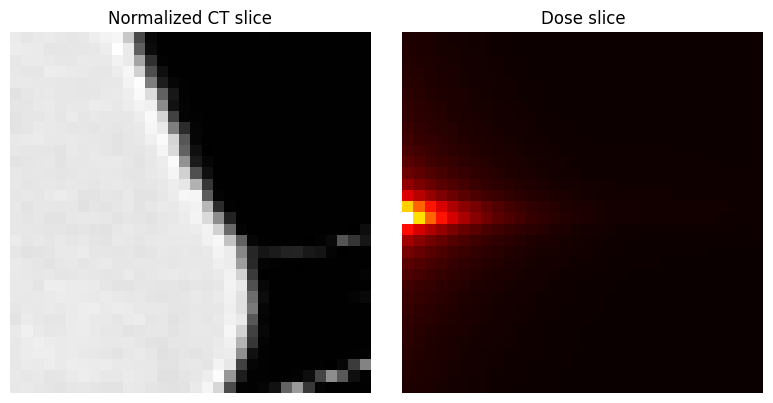

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(x0[0].numpy(), cmap="gray")
axes[0].set_title("Normalized CT slice")
axes[0].axis("off")

axes[1].imshow(x1[0].numpy(), cmap="hot")
axes[1].set_title("Dose slice")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### 5. Test DataLoader

In [16]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=0)

batch_x0, batch_x1 = next(iter(train_loader))

print("batch_x0 shape:", batch_x0.shape)
print("batch_x1 shape:", batch_x1.shape)
print("batch_x0 dtype:", batch_x0.dtype)
print("batch_x1 dtype:", batch_x1.dtype)

batch_x0 shape: torch.Size([8, 1, 32, 32])
batch_x1 shape: torch.Size([8, 1, 32, 32])
batch_x0 dtype: torch.float32
batch_x1 dtype: torch.float32


### 6. Check if the values of a few batches are stable

In [17]:
for i, (bx0, bx1) in enumerate(train_loader):
    print(f"Batch {i}")
    print("  x0 min/max:", bx0.min().item(), bx0.max().item())
    print("  x1 min/max:", bx1.min().item(), bx1.max().item())
    if i == 2:
        break

Batch 0
  x0 min/max: 0.005853353533893824 0.988628625869751
  x1 min/max: 0.00041472489829175174 3.9669322967529297
Batch 1
  x0 min/max: 0.0 1.0
  x1 min/max: 0.0004968141438439488 3.88905668258667
Batch 2
  x0 min/max: 0.0004985827254131436 0.98370760679245
  x1 min/max: 0.0006063466425985098 3.918471336364746


### 1. Prepare dataset and a small subset

In [18]:
import torch
from torch.utils.data import DataLoader, Subset

# Use the tested dataset
train_dataset = CubeSlice2DDataset(train_manifest, dose_scale=1000.0)
test_dataset  = CubeSlice2DDataset(test_manifest, dose_scale=1000.0)

# First do a small scale of overfitting/validation subset
small_train_dataset = Subset(train_dataset, list(range(256)))
small_test_dataset  = Subset(test_dataset, list(range(64)))

train_loader = DataLoader(small_train_dataset, batch_size=16, shuffle=True, num_workers=0)
test_loader  = DataLoader(small_test_dataset, batch_size=16, shuffle=False, num_workers=0)

print("small train size:", len(small_train_dataset))
print("small test size :", len(small_test_dataset))

small train size: 256
small test size : 64


### 2. Define a minimal 2D time-conditioned model

In [19]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleFlowCNN2D(nn.Module):
    def __init__(self, in_channels=2, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, hidden, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(hidden, hidden, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(hidden, hidden, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(hidden, 1, kernel_size=3, padding=1)
        )

    def forward(self, xt, t):
        # xt: (B,1,H,W)
        # t : (B,1,1,1)
        t_map = t.expand(-1, 1, xt.shape[2], xt.shape[3])   # (B,1,H,W)
        inp = torch.cat([xt, t_map], dim=1)                 # (B,2,H,W)
        return self.net(inp)

### 3. Establish training setup

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

model = SimpleFlowCNN2D(hidden=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

device: cuda


### 4. Define a training step for rectified flow

In [21]:
def flow_matching_loss(model, x0, x1):
    """
    x0, x1: (B,1,H,W)
    """
    B = x0.shape[0]
    t = torch.rand(B, 1, 1, 1, device=x0.device)

    xt = (1.0 - t) * x0 + t * x1
    target_velocity = x1 - x0

    pred_velocity = model(xt, t)

    loss = F.mse_loss(pred_velocity, target_velocity)
    return loss

### 5. Train a minimal version first

In [22]:
num_epochs = 10
train_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for x0, x1 in train_loader:
        x0 = x0.to(device)
        x1 = x1.to(device)

        optimizer.zero_grad()
        loss = flow_matching_loss(model, x0, x1)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - train loss: {epoch_loss:.6f}")

Epoch 1/10 - train loss: 0.073566
Epoch 2/10 - train loss: 0.053144
Epoch 3/10 - train loss: 0.039229
Epoch 4/10 - train loss: 0.034388
Epoch 5/10 - train loss: 0.032950
Epoch 6/10 - train loss: 0.030812
Epoch 7/10 - train loss: 0.028794
Epoch 8/10 - train loss: 0.027583
Epoch 9/10 - train loss: 0.025830
Epoch 10/10 - train loss: 0.024817


### 6. Plot loss curve

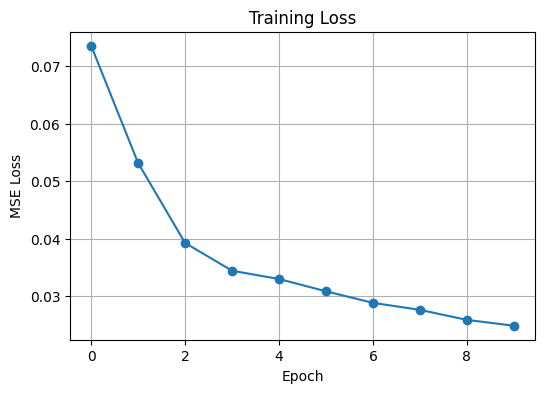

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(train_losses, marker="o")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

### 7. Define Euler sampling function

In [24]:
@torch.no_grad()
def euler_sample(model, x0, n_steps=20):
    """
    x0: (B,1,H,W)
    """
    model.eval()
    z = x0.clone()

    dt = 1.0 / n_steps

    for k in range(n_steps):
        t = torch.full((z.shape[0], 1, 1, 1), k / n_steps, device=z.device)
        v = model(z, t)
        z = z + dt * v

    return z

### 8. View a few prediction results

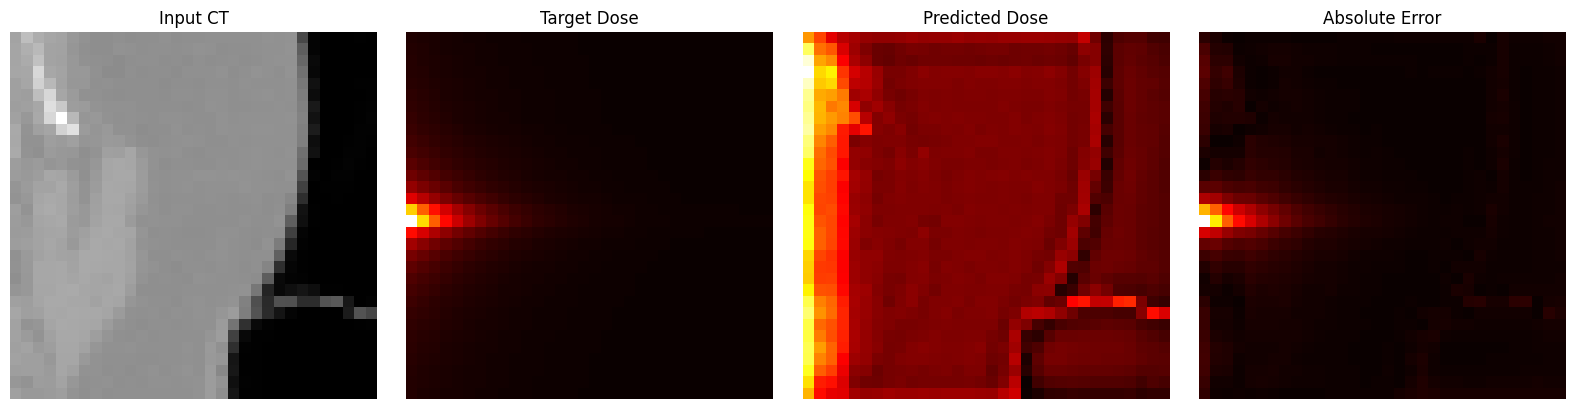

In [25]:
model.eval()

x0, x1 = next(iter(test_loader))
x0 = x0.to(device)
x1 = x1.to(device)

pred = euler_sample(model, x0, n_steps=20)

x0_np = x0[0,0].cpu().numpy()
x1_np = x1[0,0].cpu().numpy()
pred_np = pred[0,0].cpu().numpy()
err_np = abs(pred_np - x1_np)

fig, axes = plt.subplots(1, 4, figsize=(16,4))

axes[0].imshow(x0_np, cmap="gray")
axes[0].set_title("Input CT")
axes[0].axis("off")

axes[1].imshow(x1_np, cmap="hot")
axes[1].set_title("Target Dose")
axes[1].axis("off")

axes[2].imshow(pred_np, cmap="hot")
axes[2].set_title("Predicted Dose")
axes[2].axis("off")

axes[3].imshow(err_np, cmap="hot")
axes[3].set_title("Absolute Error")
axes[3].axis("off")

plt.tight_layout()
plt.show()

### 9. Save checkpoint to Drive

In [26]:
from pathlib import Path

CKPT_DIR = Path("/content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints")
CKPT_DIR.mkdir(parents=True, exist_ok=True)

ckpt_path = CKPT_DIR / "simple_rf_2d_small.pt"

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "train_losses": train_losses,
    "dose_scale": 1000.0,
}, ckpt_path)

print("Saved checkpoint to:", ckpt_path)

Saved checkpoint to: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/simple_rf_2d_small.pt


### 1. Import dependencies (using conditional 2D rectified flow for training)

In [4]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

### 2. Define dataset

In [5]:
def normalize_ct(x):
    x = np.clip(x, -1024.0, 1500.0)
    x = (x + 1024.0) / (1500.0 + 1024.0)
    return x.astype(np.float32)


class CubeSlice2DDataset(Dataset):
    def __init__(self, manifest_path, dose_scale=1000.0):
        with open(manifest_path, "r", encoding="utf-8") as f:
            self.records = json.load(f)
        self.dose_scale = dose_scale

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]

        x0_3d = np.load(rec["input_path"]).astype(np.float32)
        x1_3d = np.load(rec["output_path"]).astype(np.float32)

        s = rec["slice_index"]

        x0 = x0_3d[s]   # (H, W)
        x1 = x1_3d[s]   # (H, W)

        x0 = normalize_ct(x0)
        x1 = (x1 * self.dose_scale).astype(np.float32)

        x0 = torch.from_numpy(x0).unsqueeze(0)   # (1, H, W)
        x1 = torch.from_numpy(x1).unsqueeze(0)   # (1, H, W)

        return x0, x1

### 3. Read manifest, first make a small overfitting subset

In [29]:
train_manifest = Path("/content/drive/MyDrive/rectified_flow_ct2dose/data/splits/train_pairs_2d.json")
test_manifest  = Path("/content/drive/MyDrive/rectified_flow_ct2dose/data/splits/test_pairs_2d.json")

train_dataset = CubeSlice2DDataset(train_manifest, dose_scale=1000.0)
test_dataset  = CubeSlice2DDataset(test_manifest, dose_scale=1000.0)

small_train_dataset = Subset(train_dataset, list(range(32)))
small_test_dataset  = Subset(test_dataset, list(range(16)))

train_loader = DataLoader(small_train_dataset, batch_size=8, shuffle=True, num_workers=0)
test_loader  = DataLoader(small_test_dataset, batch_size=8, shuffle=False, num_workers=0)

print("small train size:", len(small_train_dataset))
print("small test size :", len(small_test_dataset))

small train size: 32
small test size : 16


### 4. Define conditional 2D flow model

In [14]:
class ConditionalFlowCNN2D(nn.Module):
    def __init__(self, in_channels=3, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, hidden, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(hidden, hidden, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(hidden, hidden, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(hidden, 1, kernel_size=3, padding=1)
        )

    def forward(self, xt, x0, t):
        # xt: (B,1,H,W)
        # x0: (B,1,H,W)
        # t : (B,1,1,1)
        t_map = t.expand(-1, 1, xt.shape[2], xt.shape[3])   # (B,1,H,W)
        inp = torch.cat([xt, x0, t_map], dim=1)             # (B,3,H,W)
        return self.net(inp)

### 5. Device and optimizer

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

model = ConditionalFlowCNN2D(hidden=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

device: cuda


### 6. Define conditional flow matching loss

In [32]:
def flow_matching_loss(model, x0, x1):
    """
    x0, x1: (B,1,H,W)
    """
    B = x0.shape[0]
    t = torch.rand(B, 1, 1, 1, device=x0.device)

    xt = (1.0 - t) * x0 + t * x1
    target_velocity = x1 - x0

    pred_velocity = model(xt, x0, t)

    loss = F.mse_loss(pred_velocity, target_velocity)
    return loss

### 7. Training loop

In [33]:
num_epochs = 30
train_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for x0, x1 in train_loader:
        x0 = x0.to(device)
        x1 = x1.to(device)

        optimizer.zero_grad()
        loss = flow_matching_loss(model, x0, x1)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1}/{num_epochs} - train loss: {epoch_loss:.6f}")

Epoch 1/30 - train loss: 0.111365
Epoch 2/30 - train loss: 0.076908
Epoch 3/30 - train loss: 0.063569
Epoch 4/30 - train loss: 0.053924
Epoch 5/30 - train loss: 0.043178
Epoch 6/30 - train loss: 0.033710
Epoch 7/30 - train loss: 0.028252
Epoch 8/30 - train loss: 0.026413
Epoch 9/30 - train loss: 0.023417
Epoch 10/30 - train loss: 0.019950
Epoch 11/30 - train loss: 0.019764
Epoch 12/30 - train loss: 0.018334
Epoch 13/30 - train loss: 0.014140
Epoch 14/30 - train loss: 0.014453
Epoch 15/30 - train loss: 0.011928
Epoch 16/30 - train loss: 0.010488
Epoch 17/30 - train loss: 0.009496
Epoch 18/30 - train loss: 0.009860
Epoch 19/30 - train loss: 0.012124
Epoch 20/30 - train loss: 0.009690
Epoch 21/30 - train loss: 0.009923
Epoch 22/30 - train loss: 0.008975
Epoch 23/30 - train loss: 0.007290
Epoch 24/30 - train loss: 0.008396
Epoch 25/30 - train loss: 0.005928
Epoch 26/30 - train loss: 0.007927
Epoch 27/30 - train loss: 0.007739
Epoch 28/30 - train loss: 0.007916
Epoch 29/30 - train loss: 0.0

### 8. Plot loss curve

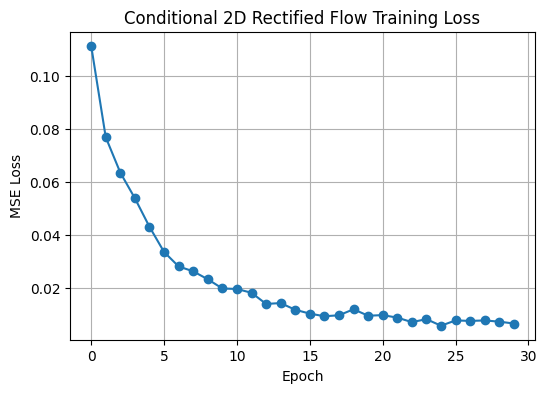

In [34]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses, marker="o")
plt.title("Conditional 2D Rectified Flow Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

### 9. Define conditional Euler sampler

In [35]:
@torch.no_grad()
def euler_sample(model, x0, n_steps=50):
    """
    x0: (B,1,H,W)
    """
    model.eval()
    z = x0.clone()
    dt = 1.0 / n_steps

    for k in range(n_steps):
        t = torch.full((z.shape[0], 1, 1, 1), k / n_steps, device=z.device)
        v = model(z, x0, t)
        z = z + dt * v

    return z

### 10. View prediction results on test samples

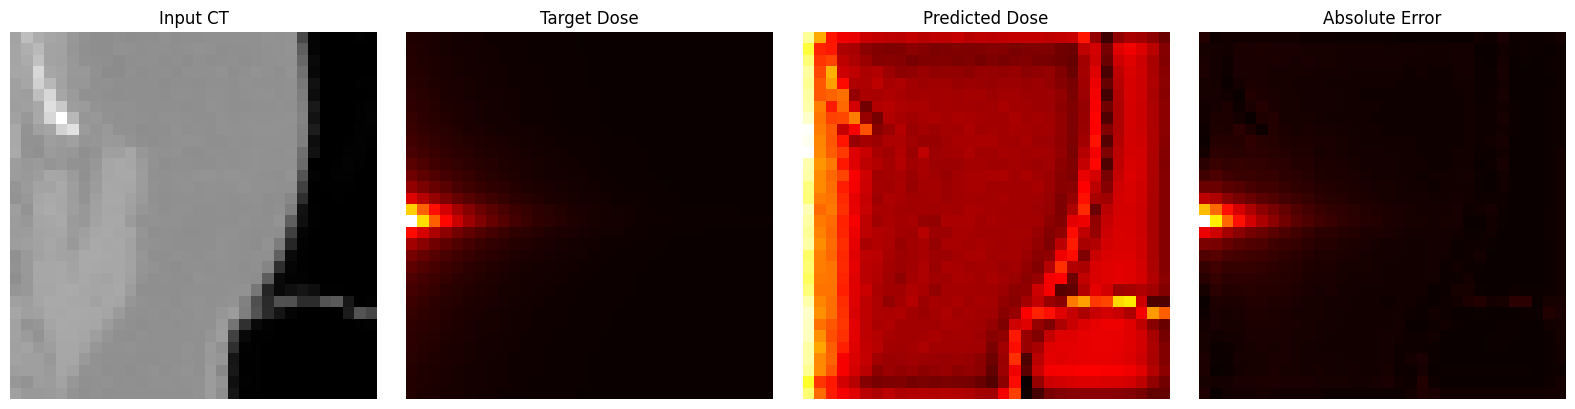

In [36]:
model.eval()

x0, x1 = next(iter(test_loader))
x0 = x0.to(device)
x1 = x1.to(device)

pred = euler_sample(model, x0, n_steps=50)

x0_np = x0[0, 0].cpu().numpy()
x1_np = x1[0, 0].cpu().numpy()
pred_np = pred[0, 0].cpu().numpy()
err_np = np.abs(pred_np - x1_np)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(x0_np, cmap="gray")
axes[0].set_title("Input CT")
axes[0].axis("off")

axes[1].imshow(x1_np, cmap="hot")
axes[1].set_title("Target Dose")
axes[1].axis("off")

axes[2].imshow(pred_np, cmap="hot")
axes[2].set_title("Predicted Dose")
axes[2].axis("off")

axes[3].imshow(err_np, cmap="hot")
axes[3].set_title("Absolute Error")
axes[3].axis("off")

plt.tight_layout()
plt.show()

### 11. Compute a simple test error along the way

In [37]:
with torch.no_grad():
    mse = F.mse_loss(pred, x1).item()
print("Test batch MSE:", mse)

Test batch MSE: 0.030984217301011086


### 12. Save checkpoint

In [38]:
CKPT_DIR = Path("/content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints")
CKPT_DIR.mkdir(parents=True, exist_ok=True)

ckpt_path = CKPT_DIR / "conditional_rf_2d_small.pt"

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "train_losses": train_losses,
    "dose_scale": 1000.0,
    "num_epochs": num_epochs,
}, ckpt_path)

print("Saved checkpoint to:", ckpt_path)

Saved checkpoint to: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/conditional_rf_2d_small.pt


### 13. Evaluate the same conditional flow model on a train batch

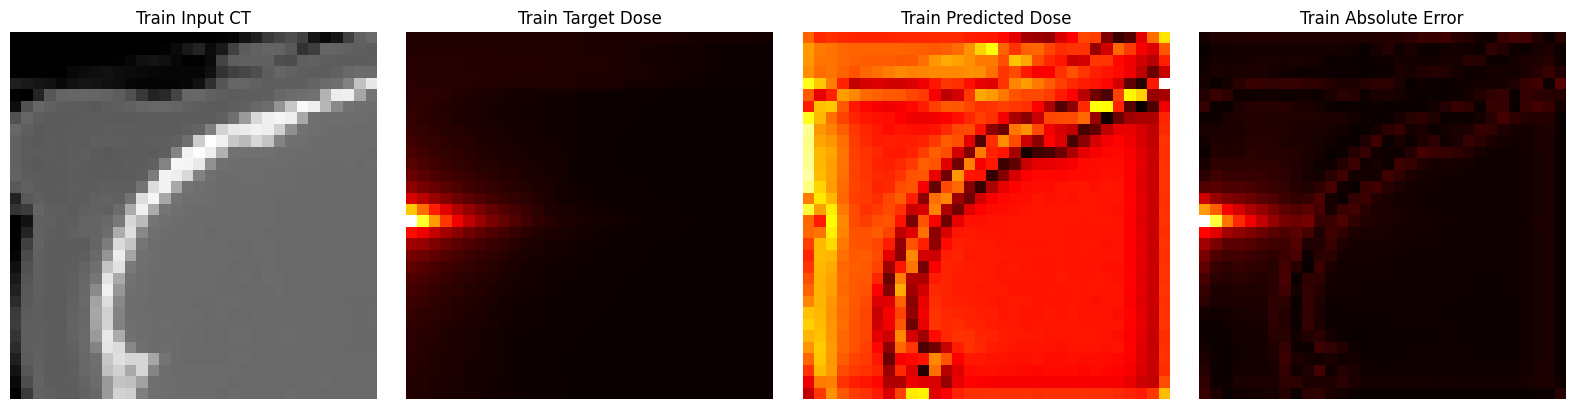

Train batch MSE: 0.03678124025464058


In [39]:
model.eval()

x0, x1 = next(iter(train_loader))   # here changes into train_loader
x0 = x0.to(device)
x1 = x1.to(device)

pred = euler_sample(model, x0, n_steps=50)

x0_np = x0[0, 0].cpu().numpy()
x1_np = x1[0, 0].cpu().numpy()
pred_np = pred[0, 0].cpu().numpy()
err_np = np.abs(pred_np - x1_np)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(x0_np, cmap="gray")
axes[0].set_title("Train Input CT")
axes[0].axis("off")

axes[1].imshow(x1_np, cmap="hot")
axes[1].set_title("Train Target Dose")
axes[1].axis("off")

axes[2].imshow(pred_np, cmap="hot")
axes[2].set_title("Train Predicted Dose")
axes[2].axis("off")

axes[3].imshow(err_np, cmap="hot")
axes[3].set_title("Train Absolute Error")
axes[3].axis("off")

plt.tight_layout()
plt.show()

with torch.no_grad():
    mse = F.mse_loss(pred, x1).item()
print("Train batch MSE:", mse)

### 1. First use a very small subset for overfitting

In [40]:
from pathlib import Path

train_manifest = Path("/content/drive/MyDrive/rectified_flow_ct2dose/data/splits/train_pairs_2d.json")
test_manifest  = Path("/content/drive/MyDrive/rectified_flow_ct2dose/data/splits/test_pairs_2d.json")

train_dataset = CubeSlice2DDataset(train_manifest, dose_scale=1000.0)
test_dataset  = CubeSlice2DDataset(test_manifest, dose_scale=1000.0)

small_train_dataset = Subset(train_dataset, list(range(32)))
small_test_dataset  = Subset(test_dataset, list(range(16)))

train_loader = DataLoader(small_train_dataset, batch_size=8, shuffle=True, num_workers=0)
test_loader  = DataLoader(small_test_dataset, batch_size=8, shuffle=False, num_workers=0)

print("small train size:", len(small_train_dataset))
print("small test size :", len(small_test_dataset))

small train size: 32
small test size : 16


### 2. Define a minimal 2D U-Net

In [6]:
import torch.nn as nn
import torch.nn.functional as F


class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet2D(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base_ch=32):
        super().__init__()

        self.enc1 = DoubleConv(in_ch, base_ch)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(base_ch, base_ch * 2)
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(base_ch * 2, base_ch * 4)

        self.up2 = nn.ConvTranspose2d(base_ch * 4, base_ch * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(base_ch * 4, base_ch * 2)

        self.up1 = nn.ConvTranspose2d(base_ch * 2, base_ch, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(base_ch * 2, base_ch)

        self.out_conv = nn.Conv2d(base_ch, out_ch, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)               # (B, 32, 32, 32)
        e2 = self.enc2(self.pool1(e1))  # (B, 64, 16, 16)

        b = self.bottleneck(self.pool2(e2))  # (B, 128, 8, 8)

        d2 = self.up2(b)                # (B, 64, 16, 16)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)               # (B, 32, 32, 32)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        out = self.out_conv(d1)         # (B, 1, 32, 32)
        return out

### 3. Device, model, optimizer

In [42]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

model = UNet2D(in_ch=1, out_ch=1, base_ch=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

device: cuda


### 4. Define regression loss

In [43]:
def regression_loss(model, x0, x1):
    pred = model(x0)
    loss = F.mse_loss(pred, x1)
    return loss, pred

### 5. Training loop

In [44]:
num_epochs = 30
train_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for x0, x1 in train_loader:
        x0 = x0.to(device)
        x1 = x1.to(device)

        optimizer.zero_grad()
        loss, pred = regression_loss(model, x0, x1)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1}/{num_epochs} - train loss: {epoch_loss:.6f}")

Epoch 1/30 - train loss: 0.073529
Epoch 2/30 - train loss: 0.043097
Epoch 3/30 - train loss: 0.036357
Epoch 4/30 - train loss: 0.035367
Epoch 5/30 - train loss: 0.033677
Epoch 6/30 - train loss: 0.032760
Epoch 7/30 - train loss: 0.030885
Epoch 8/30 - train loss: 0.025986
Epoch 9/30 - train loss: 0.024206
Epoch 10/30 - train loss: 0.022848
Epoch 11/30 - train loss: 0.021515
Epoch 12/30 - train loss: 0.020144
Epoch 13/30 - train loss: 0.019590
Epoch 14/30 - train loss: 0.018818
Epoch 15/30 - train loss: 0.017839
Epoch 16/30 - train loss: 0.016939
Epoch 17/30 - train loss: 0.015146
Epoch 18/30 - train loss: 0.013070
Epoch 19/30 - train loss: 0.012272
Epoch 20/30 - train loss: 0.020530
Epoch 21/30 - train loss: 0.014561
Epoch 22/30 - train loss: 0.012198
Epoch 23/30 - train loss: 0.010848
Epoch 24/30 - train loss: 0.008903
Epoch 25/30 - train loss: 0.007144
Epoch 26/30 - train loss: 0.005681
Epoch 27/30 - train loss: 0.006444
Epoch 28/30 - train loss: 0.007523
Epoch 29/30 - train loss: 0.0

### 6. Plot loss curve

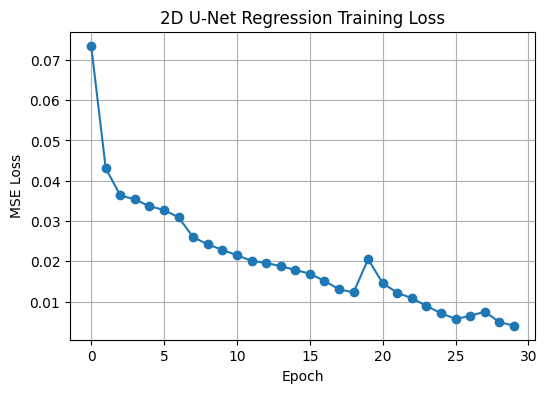

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(train_losses, marker="o")
plt.title("2D U-Net Regression Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

### 7. First check the fitting effect on the training set

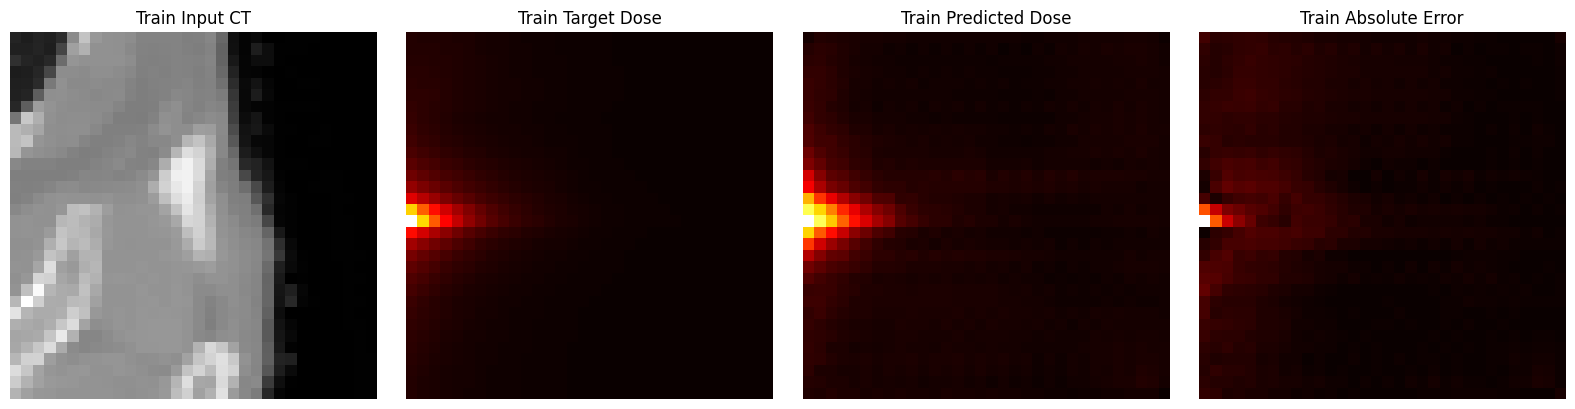

Train batch MSE: 0.004358675330877304


In [46]:
model.eval()

x0, x1 = next(iter(train_loader))
x0 = x0.to(device)
x1 = x1.to(device)

with torch.no_grad():
    pred = model(x0)

x0_np = x0[0, 0].cpu().numpy()
x1_np = x1[0, 0].cpu().numpy()
pred_np = pred[0, 0].cpu().numpy()
err_np = np.abs(pred_np - x1_np)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(x0_np, cmap="gray")
axes[0].set_title("Train Input CT")
axes[0].axis("off")

axes[1].imshow(x1_np, cmap="hot")
axes[1].set_title("Train Target Dose")
axes[1].axis("off")

axes[2].imshow(pred_np, cmap="hot")
axes[2].set_title("Train Predicted Dose")
axes[2].axis("off")

axes[3].imshow(err_np, cmap="hot")
axes[3].set_title("Train Absolute Error")
axes[3].axis("off")

plt.tight_layout()
plt.show()

with torch.no_grad():
    train_mse = F.mse_loss(pred, x1).item()
print("Train batch MSE:", train_mse)

### 8. Then check the effect on the test set

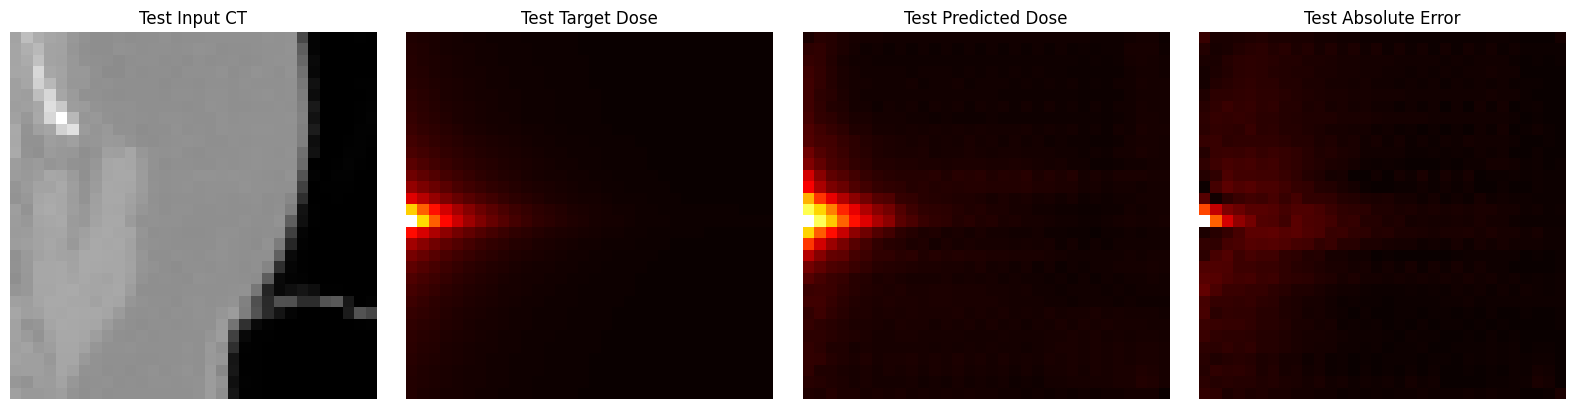

Test batch MSE: 0.003828777000308037


In [47]:
model.eval()

x0, x1 = next(iter(test_loader))
x0 = x0.to(device)
x1 = x1.to(device)

with torch.no_grad():
    pred = model(x0)

x0_np = x0[0, 0].cpu().numpy()
x1_np = x1[0, 0].cpu().numpy()
pred_np = pred[0, 0].cpu().numpy()
err_np = np.abs(pred_np - x1_np)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(x0_np, cmap="gray")
axes[0].set_title("Test Input CT")
axes[0].axis("off")

axes[1].imshow(x1_np, cmap="hot")
axes[1].set_title("Test Target Dose")
axes[1].axis("off")

axes[2].imshow(pred_np, cmap="hot")
axes[2].set_title("Test Predicted Dose")
axes[2].axis("off")

axes[3].imshow(err_np, cmap="hot")
axes[3].set_title("Test Absolute Error")
axes[3].axis("off")

plt.tight_layout()
plt.show()

with torch.no_grad():
    test_mse = F.mse_loss(pred, x1).item()
print("Test batch MSE:", test_mse)

### 9. Save checkpoint

In [48]:
from pathlib import Path

CKPT_DIR = Path("/content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints")
CKPT_DIR.mkdir(parents=True, exist_ok=True)

ckpt_path = CKPT_DIR / "unet2d_regression_small.pt"

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "train_losses": train_losses,
    "dose_scale": 1000.0,
    "num_epochs": num_epochs,
}, ckpt_path)

print("Saved checkpoint to:", ckpt_path)

Saved checkpoint to: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/unet2d_regression_small.pt


### 10. Evaluate the average error of the entire DataLoader

In [49]:
import torch
import torch.nn.functional as F

@torch.no_grad()
def evaluate_regression(model, loader, device):
    model.eval()

    total_mse = 0.0
    total_mae = 0.0
    n_batches = 0

    for x0, x1 in loader:
        x0 = x0.to(device)
        x1 = x1.to(device)

        pred = model(x0)

        mse = F.mse_loss(pred, x1).item()
        mae = F.l1_loss(pred, x1).item()

        total_mse += mse
        total_mae += mae
        n_batches += 1

    return {
        "mse": total_mse / n_batches,
        "mae": total_mae / n_batches
    }

train_metrics = evaluate_regression(model, train_loader, device)
test_metrics = evaluate_regression(model, test_loader, device)

print("Train metrics:", train_metrics)
print("Test metrics :", test_metrics)

Train metrics: {'mse': 0.003667148936074227, 'mae': 0.035559702664613724}
Test metrics : {'mse': 0.003689631586894393, 'mae': 0.03774905949831009}


### 1. Fix random seed

In [50]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

### 2. Build the dataset for the 128-sample regression baseline

In [51]:
from torch.utils.data import DataLoader, Subset

train_dataset = CubeSlice2DDataset(train_manifest, dose_scale=1000.0)
test_dataset  = CubeSlice2DDataset(test_manifest, dose_scale=1000.0)

reg_train_dataset = Subset(train_dataset, list(range(128)))
reg_test_dataset  = Subset(test_dataset, list(range(128)))

train_loader = DataLoader(reg_train_dataset, batch_size=16, shuffle=True, num_workers=0)
test_loader  = DataLoader(reg_test_dataset, batch_size=16, shuffle=False, num_workers=0)

print("reg train size:", len(reg_train_dataset))
print("reg test size :", len(reg_test_dataset))

reg train size: 128
reg test size : 128


### 3. Reinitialize a 2D U-Net regression model

In [52]:
import torch
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

model = UNet2D(in_ch=1, out_ch=1, base_ch=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

device: cuda


### 4. Define regression loss

In [53]:
def regression_loss(model, x0, x1):
    pred = model(x0)
    loss = F.mse_loss(pred, x1)
    return loss, pred

### 5. Train the 128-sample baseline

In [54]:
num_epochs = 30
train_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for x0, x1 in train_loader:
        x0 = x0.to(device)
        x1 = x1.to(device)

        optimizer.zero_grad()
        loss, pred = regression_loss(model, x0, x1)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1}/{num_epochs} - train loss: {epoch_loss:.6f}")

Epoch 1/30 - train loss: 0.039066
Epoch 2/30 - train loss: 0.031975
Epoch 3/30 - train loss: 0.028129
Epoch 4/30 - train loss: 0.023434
Epoch 5/30 - train loss: 0.021172
Epoch 6/30 - train loss: 0.019338
Epoch 7/30 - train loss: 0.017966
Epoch 8/30 - train loss: 0.018469
Epoch 9/30 - train loss: 0.014746
Epoch 10/30 - train loss: 0.010890
Epoch 11/30 - train loss: 0.007693
Epoch 12/30 - train loss: 0.004836
Epoch 13/30 - train loss: 0.002493
Epoch 14/30 - train loss: 0.003783
Epoch 15/30 - train loss: 0.003198
Epoch 16/30 - train loss: 0.002358
Epoch 17/30 - train loss: 0.001396
Epoch 18/30 - train loss: 0.001355
Epoch 19/30 - train loss: 0.001047
Epoch 20/30 - train loss: 0.000951
Epoch 21/30 - train loss: 0.000878
Epoch 22/30 - train loss: 0.000792
Epoch 23/30 - train loss: 0.000841
Epoch 24/30 - train loss: 0.000813
Epoch 25/30 - train loss: 0.000746
Epoch 26/30 - train loss: 0.000869
Epoch 27/30 - train loss: 0.000796
Epoch 28/30 - train loss: 0.000865
Epoch 29/30 - train loss: 0.0

### 6. Plot training loss curve

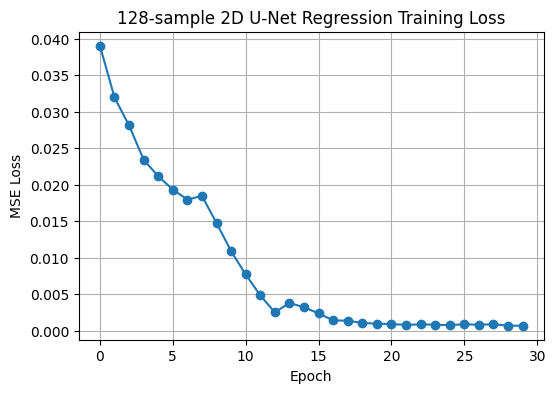

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(train_losses, marker="o")
plt.title("128-sample 2D U-Net Regression Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)

plt.show()

### 7. Evaluate average metrics of the entire train/test subset

In [56]:
@torch.no_grad()
def evaluate_regression(model, loader, device):
    model.eval()

    total_mse = 0.0
    total_mae = 0.0
    n_batches = 0

    for x0, x1 in loader:
        x0 = x0.to(device)
        x1 = x1.to(device)

        pred = model(x0)

        mse = F.mse_loss(pred, x1).item()
        mae = F.l1_loss(pred, x1).item()

        total_mse += mse
        total_mae += mae
        n_batches += 1

    return {
        "mse": total_mse / n_batches,
        "mae": total_mae / n_batches
    }

train_metrics = evaluate_regression(model, train_loader, device)
test_metrics  = evaluate_regression(model, test_loader, device)

print("Train metrics:", train_metrics)
print("Test metrics :", test_metrics)

Train metrics: {'mse': 0.0007382713083643466, 'mae': 0.014818718656897545}
Test metrics : {'mse': 0.0010621289839036763, 'mae': 0.016884959070011973}


### 8. Visualize a set of results on the training set

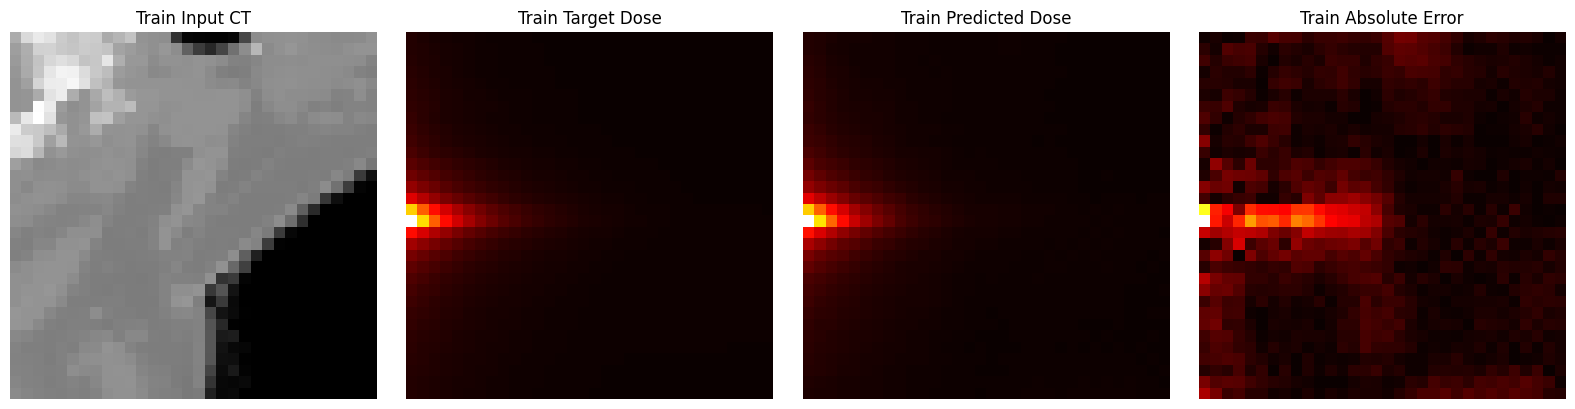

In [57]:
model.eval()

x0, x1 = next(iter(train_loader))
x0 = x0.to(device)
x1 = x1.to(device)

with torch.no_grad():
    pred = model(x0)

x0_np = x0[0, 0].cpu().numpy()
x1_np = x1[0, 0].cpu().numpy()
pred_np = pred[0, 0].cpu().numpy()
err_np = np.abs(pred_np - x1_np)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(x0_np, cmap="gray")
axes[0].set_title("Train Input CT")
axes[0].axis("off")

axes[1].imshow(x1_np, cmap="hot")
axes[1].set_title("Train Target Dose")
axes[1].axis("off")

axes[2].imshow(pred_np, cmap="hot")
axes[2].set_title("Train Predicted Dose")
axes[2].axis("off")

axes[3].imshow(err_np, cmap="hot")
axes[3].set_title("Train Absolute Error")
axes[3].axis("off")

plt.tight_layout()

plt.show()

### 9. Visualize a set of results on the test set

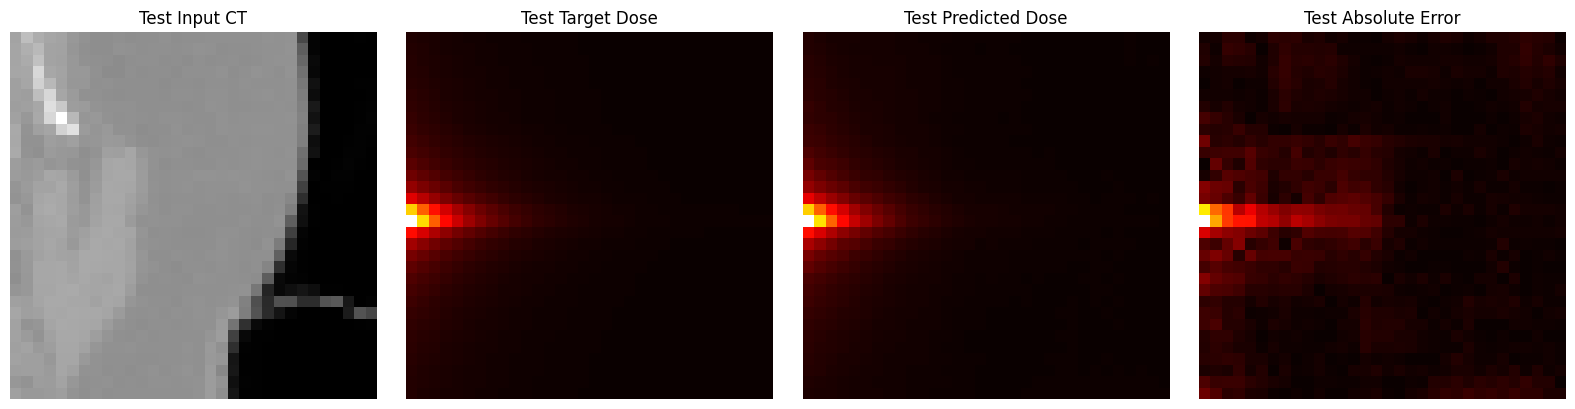

In [58]:
model.eval()

x0, x1 = next(iter(test_loader))
x0 = x0.to(device)
x1 = x1.to(device)

with torch.no_grad():
    pred = model(x0)

x0_np = x0[0, 0].cpu().numpy()
x1_np = x1[0, 0].cpu().numpy()
pred_np = pred[0, 0].cpu().numpy()
err_np = np.abs(pred_np - x1_np)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(x0_np, cmap="gray")
axes[0].set_title("Test Input CT")
axes[0].axis("off")

axes[1].imshow(x1_np, cmap="hot")
axes[1].set_title("Test Target Dose")
axes[1].axis("off")

axes[2].imshow(pred_np, cmap="hot")
axes[2].set_title("Test Predicted Dose")
axes[2].axis("off")

axes[3].imshow(err_np, cmap="hot")
axes[3].set_title("Test Absolute Error")
axes[3].axis("off")

plt.tight_layout()
plt.show()

### 10. Save checkpoint

In [59]:
from pathlib import Path

CKPT_DIR = Path("/content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints")
CKPT_DIR.mkdir(parents=True, exist_ok=True)

ckpt_path = CKPT_DIR / "unet2d_regression_128samples.pt"

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "train_losses": train_losses,
    "train_metrics": train_metrics,
    "test_metrics": test_metrics,
    "dose_scale": 1000.0,
    "num_epochs": num_epochs,
    "num_train_samples": 128,
    "num_test_samples": 128,
}, ckpt_path)

print("Saved checkpoint to:", ckpt_path)

Saved checkpoint to: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/unet2d_regression_128samples.pt


### 1. Import dependencies (based on conditional 2D U-Net flow baseline)

In [60]:
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

### 2. Fix random seed

In [61]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

### 3. Define dataset

In [62]:
def normalize_ct(x):
    x = np.clip(x, -1024.0, 1500.0)
    x = (x + 1024.0) / (1500.0 + 1024.0)
    return x.astype(np.float32)


class CubeSlice2DDataset(Dataset):
    def __init__(self, manifest_path, dose_scale=1000.0):
        with open(manifest_path, "r", encoding="utf-8") as f:
            self.records = json.load(f)
        self.dose_scale = dose_scale

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]

        x0_3d = np.load(rec["input_path"]).astype(np.float32)
        x1_3d = np.load(rec["output_path"]).astype(np.float32)

        s = rec["slice_index"]

        x0 = x0_3d[s]
        x1 = x1_3d[s]

        x0 = normalize_ct(x0)
        x1 = (x1 * self.dose_scale).astype(np.float32)

        x0 = torch.from_numpy(x0).unsqueeze(0)   # (1, 32, 32)
        x1 = torch.from_numpy(x1).unsqueeze(0)   # (1, 32, 32)

        return x0, x1

### 4. Read manifest, first fix the 128-sample subset

In [63]:
train_manifest = Path("/content/drive/MyDrive/rectified_flow_ct2dose/data/splits/train_pairs_2d.json")
test_manifest  = Path("/content/drive/MyDrive/rectified_flow_ct2dose/data/splits/test_pairs_2d.json")

train_dataset = CubeSlice2DDataset(train_manifest, dose_scale=1000.0)
test_dataset  = CubeSlice2DDataset(test_manifest, dose_scale=1000.0)

flow_train_dataset = Subset(train_dataset, list(range(128)))
flow_test_dataset  = Subset(test_dataset, list(range(128)))

train_loader = DataLoader(flow_train_dataset, batch_size=16, shuffle=True, num_workers=0)
test_loader  = DataLoader(flow_test_dataset, batch_size=16, shuffle=False, num_workers=0)

print("flow train size:", len(flow_train_dataset))
print("flow test size :", len(flow_test_dataset))

flow train size: 128
flow test size : 128


### 5. Define conditional U-Net

In [12]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class ConditionalUNetFlow2D(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, base_ch=32):
        super().__init__()

        self.enc1 = DoubleConv(in_ch, base_ch)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(base_ch, base_ch * 2)
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(base_ch * 2, base_ch * 4)

        self.up2 = nn.ConvTranspose2d(base_ch * 4, base_ch * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(base_ch * 4, base_ch * 2)

        self.up1 = nn.ConvTranspose2d(base_ch * 2, base_ch, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(base_ch * 2, base_ch)

        self.out_conv = nn.Conv2d(base_ch, out_ch, kernel_size=1)

    def forward(self, xt, x0, t):
        # xt, x0: (B,1,H,W)
        # t: (B,1,1,1)
        t_map = t.expand(-1, 1, xt.shape[2], xt.shape[3])   # (B,1,H,W)
        inp = torch.cat([xt, x0, t_map], dim=1)             # (B,3,H,W)

        e1 = self.enc1(inp)
        e2 = self.enc2(self.pool1(e1))

        b = self.bottleneck(self.pool2(e2))

        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        out = self.out_conv(d1)   # predicted velocity
        return out

### 6. Device, model, optimizer

In [65]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

model = ConditionalUNetFlow2D(in_ch=3, out_ch=1, base_ch=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

device: cuda


### 7. Define flow matching loss

In [66]:
def flow_matching_loss(model, x0, x1):
    """
    x0, x1: (B,1,H,W)
    """
    B = x0.shape[0]
    t = torch.rand(B, 1, 1, 1, device=x0.device)

    xt = (1.0 - t) * x0 + t * x1
    target_velocity = x1 - x0

    pred_velocity = model(xt, x0, t)

    loss = F.mse_loss(pred_velocity, target_velocity)
    return loss

### (2)Generic Save Function

In [80]:
def save_fig(fig, save_path):
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print("Saved:", save_path)


def save_loss_curve(train_losses, title, save_path):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(train_losses, marker="o")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.grid(True)
    save_fig(fig, save_path)
    plt.show()


def save_prediction_panel(x0_np, x1_np, pred_np, save_path, prefix=""):
    err_np = np.abs(pred_np - x1_np)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(x0_np, cmap="gray")
    axes[0].set_title(f"{prefix}Input CT")
    axes[0].axis("off")

    axes[1].imshow(x1_np, cmap="hot")
    axes[1].set_title(f"{prefix}Target Dose")
    axes[1].axis("off")

    axes[2].imshow(pred_np, cmap="hot")
    axes[2].set_title(f"{prefix}Predicted Dose")
    axes[2].axis("off")

    axes[3].imshow(np.abs(pred_np - x1_np), cmap="hot")
    axes[3].set_title(f"{prefix}Absolute Error")
    axes[3].axis("off")

    plt.tight_layout()
    save_fig(fig, save_path)
    plt.show()

### 8. Train conditional U-Net flow

In [67]:
num_epochs = 30
train_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for x0, x1 in train_loader:
        x0 = x0.to(device)
        x1 = x1.to(device)

        optimizer.zero_grad()
        loss = flow_matching_loss(model, x0, x1)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1}/{num_epochs} - train loss: {epoch_loss:.6f}")

Epoch 1/30 - train loss: 0.124046
Epoch 2/30 - train loss: 0.053939
Epoch 3/30 - train loss: 0.039007
Epoch 4/30 - train loss: 0.028897
Epoch 5/30 - train loss: 0.025327
Epoch 6/30 - train loss: 0.021942
Epoch 7/30 - train loss: 0.017478
Epoch 8/30 - train loss: 0.015310
Epoch 9/30 - train loss: 0.011815
Epoch 10/30 - train loss: 0.009699
Epoch 11/30 - train loss: 0.008027
Epoch 12/30 - train loss: 0.006920
Epoch 13/30 - train loss: 0.005777
Epoch 14/30 - train loss: 0.004965
Epoch 15/30 - train loss: 0.004045
Epoch 16/30 - train loss: 0.004117
Epoch 17/30 - train loss: 0.003900
Epoch 18/30 - train loss: 0.004023
Epoch 19/30 - train loss: 0.003212
Epoch 20/30 - train loss: 0.002801
Epoch 21/30 - train loss: 0.002400
Epoch 22/30 - train loss: 0.002222
Epoch 23/30 - train loss: 0.002005
Epoch 24/30 - train loss: 0.001835
Epoch 25/30 - train loss: 0.001645
Epoch 26/30 - train loss: 0.001541
Epoch 27/30 - train loss: 0.001500
Epoch 28/30 - train loss: 0.001367
Epoch 29/30 - train loss: 0.0

### 9. Plot training loss curve

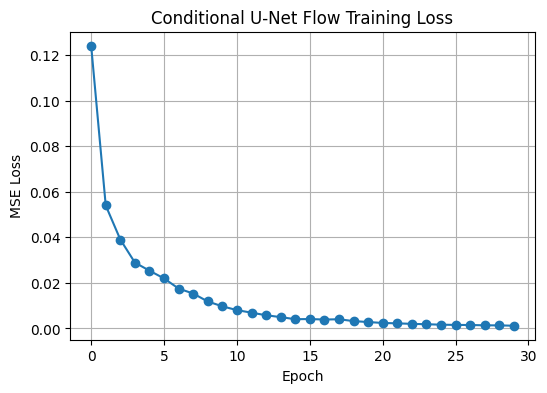

In [68]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses, marker="o")
plt.title("Conditional U-Net Flow Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

### 10. Define Euler sampler

In [69]:
@torch.no_grad()
def euler_sample(model, x0, n_steps=50):
    """
    x0: (B,1,H,W)
    """
    model.eval()
    z = x0.clone()
    dt = 1.0 / n_steps

    for k in range(n_steps):
        t = torch.full((z.shape[0], 1, 1, 1), k / n_steps, device=z.device)
        v = model(z, x0, t)
        z = z + dt * v

    return z

### 11. First check the results on the training set

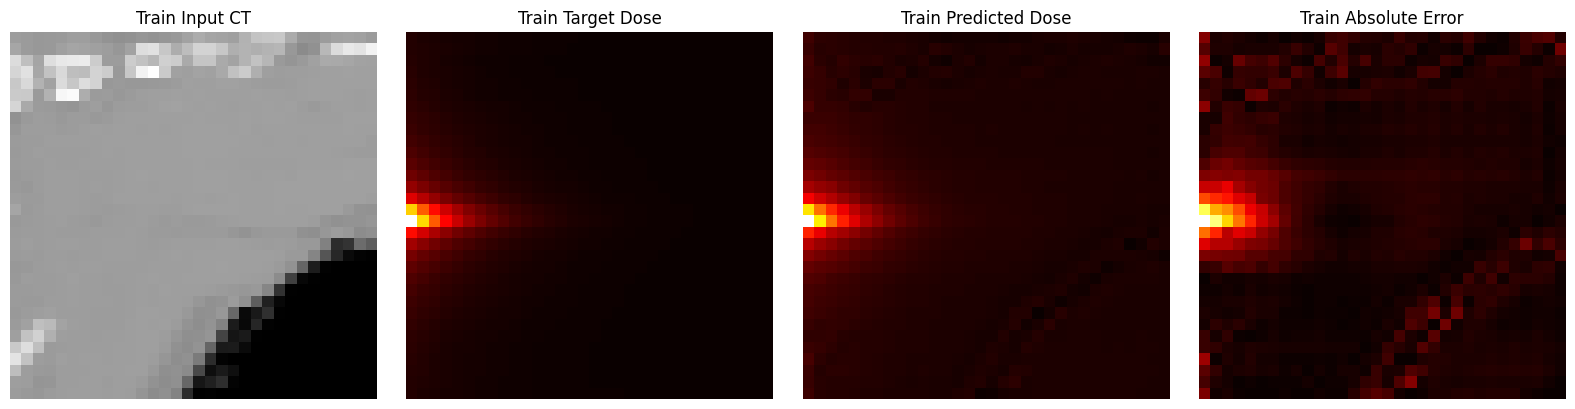

Train batch MSE: 0.0030853331554681063


In [70]:
model.eval()

x0, x1 = next(iter(train_loader))
x0 = x0.to(device)
x1 = x1.to(device)

pred = euler_sample(model, x0, n_steps=50)

x0_np = x0[0, 0].cpu().numpy()
x1_np = x1[0, 0].cpu().numpy()
pred_np = pred[0, 0].cpu().numpy()
err_np = np.abs(pred_np - x1_np)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(x0_np, cmap="gray")
axes[0].set_title("Train Input CT")
axes[0].axis("off")

axes[1].imshow(x1_np, cmap="hot")
axes[1].set_title("Train Target Dose")
axes[1].axis("off")

axes[2].imshow(pred_np, cmap="hot")
axes[2].set_title("Train Predicted Dose")
axes[2].axis("off")

axes[3].imshow(err_np, cmap="hot")
axes[3].set_title("Train Absolute Error")
axes[3].axis("off")

plt.tight_layout()
plt.show()

with torch.no_grad():
    train_batch_mse = F.mse_loss(pred, x1).item()
print("Train batch MSE:", train_batch_mse)

### 12. Then check the results on the test set

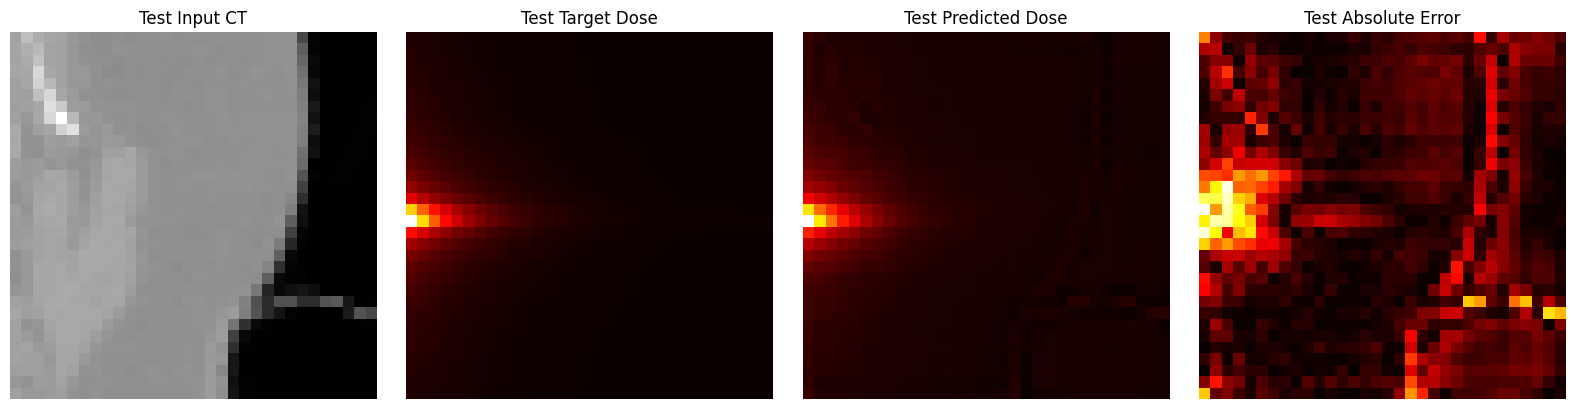

Test batch MSE: 0.003938945941627026


In [71]:
model.eval()

x0, x1 = next(iter(test_loader))
x0 = x0.to(device)
x1 = x1.to(device)

pred = euler_sample(model, x0, n_steps=50)

x0_np = x0[0, 0].cpu().numpy()
x1_np = x1[0, 0].cpu().numpy()
pred_np = pred[0, 0].cpu().numpy()
err_np = np.abs(pred_np - x1_np)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(x0_np, cmap="gray")
axes[0].set_title("Test Input CT")
axes[0].axis("off")

axes[1].imshow(x1_np, cmap="hot")
axes[1].set_title("Test Target Dose")
axes[1].axis("off")

axes[2].imshow(pred_np, cmap="hot")
axes[2].set_title("Test Predicted Dose")
axes[2].axis("off")

axes[3].imshow(err_np, cmap="hot")
axes[3].set_title("Test Absolute Error")
axes[3].axis("off")

plt.tight_layout()
plt.show()

with torch.no_grad():
    test_batch_mse = F.mse_loss(pred, x1).item()
print("Test batch MSE:", test_batch_mse)

### 13. Evaluate average metrics of the entire train/test subset

In [72]:
@torch.no_grad()
def evaluate_flow(model, loader, device, n_steps=50):
    model.eval()

    total_mse = 0.0
    total_mae = 0.0
    n_batches = 0

    for x0, x1 in loader:
        x0 = x0.to(device)
        x1 = x1.to(device)

        pred = euler_sample(model, x0, n_steps=n_steps)

        mse = F.mse_loss(pred, x1).item()
        mae = F.l1_loss(pred, x1).item()

        total_mse += mse
        total_mae += mae
        n_batches += 1

    return {
        "mse": total_mse / n_batches,
        "mae": total_mae / n_batches
    }

train_metrics = evaluate_flow(model, train_loader, device, n_steps=50)
test_metrics  = evaluate_flow(model, test_loader, device, n_steps=50)

print("Train metrics:", train_metrics)
print("Test metrics :", test_metrics)

Train metrics: {'mse': 0.003398113389266655, 'mae': 0.0332448692061007}
Test metrics : {'mse': 0.0044142070692032576, 'mae': 0.037730286829173565}


### 14. Save checkpoint

In [73]:
CKPT_DIR = Path("/content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints")
CKPT_DIR.mkdir(parents=True, exist_ok=True)

ckpt_path = CKPT_DIR / "conditional_unet_flow_2d_128samples.pt"

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "train_losses": train_losses,
    "train_metrics": train_metrics,
    "test_metrics": test_metrics,
    "dose_scale": 1000.0,
    "num_epochs": num_epochs,
    "num_train_samples": 128,
    "num_test_samples": 128,
}, ckpt_path)

print("Saved checkpoint to:", ckpt_path)

Saved checkpoint to: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/conditional_unet_flow_2d_128samples.pt


### (3)Prepare Dataset and Fix Sample Indices

In [81]:
train_manifest = Path("/content/drive/MyDrive/rectified_flow_ct2dose/data/splits/train_pairs_2d.json")
test_manifest  = Path("/content/drive/MyDrive/rectified_flow_ct2dose/data/splits/test_pairs_2d.json")

train_dataset = CubeSlice2DDataset(train_manifest, dose_scale=1000.0)
test_dataset  = CubeSlice2DDataset(test_manifest, dose_scale=1000.0)

reg_train_subset = Subset(train_dataset, list(range(128)))
reg_test_subset  = Subset(test_dataset, list(range(128)))

print("train subset size:", len(reg_train_subset))
print("test subset size :", len(reg_test_subset))


train subset size: 128
test subset size : 128


### (4)Load Regression Checkpoint

In [82]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

reg_ckpt_path = Path("/content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/unet2d_regression_128samples.pt")
print("exists:", reg_ckpt_path.exists())

reg_ckpt = torch.load(reg_ckpt_path, map_location=device)

reg_model = UNet2D(in_ch=1, out_ch=1, base_ch=32).to(device)
reg_model.load_state_dict(reg_ckpt["model_state_dict"])
reg_model.eval()

print(reg_ckpt.keys())

device: cuda
exists: True
dict_keys(['model_state_dict', 'optimizer_state_dict', 'train_losses', 'train_metrics', 'test_metrics', 'dose_scale', 'num_epochs', 'num_train_samples', 'num_test_samples'])


### (5)Reconstruct Regression Loss Curve

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/regression_128/loss_curve.png


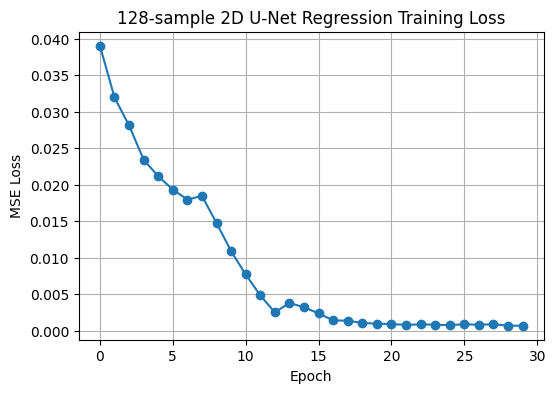

In [83]:
save_loss_curve(
    reg_ckpt["train_losses"],
    title="128-sample 2D U-Net Regression Training Loss",
    save_path=FIG_ROOT / "regression_128" / "loss_curve.png"
)

### (6)Reconstruct Regression Training Plots

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/regression_128/train_examples.png


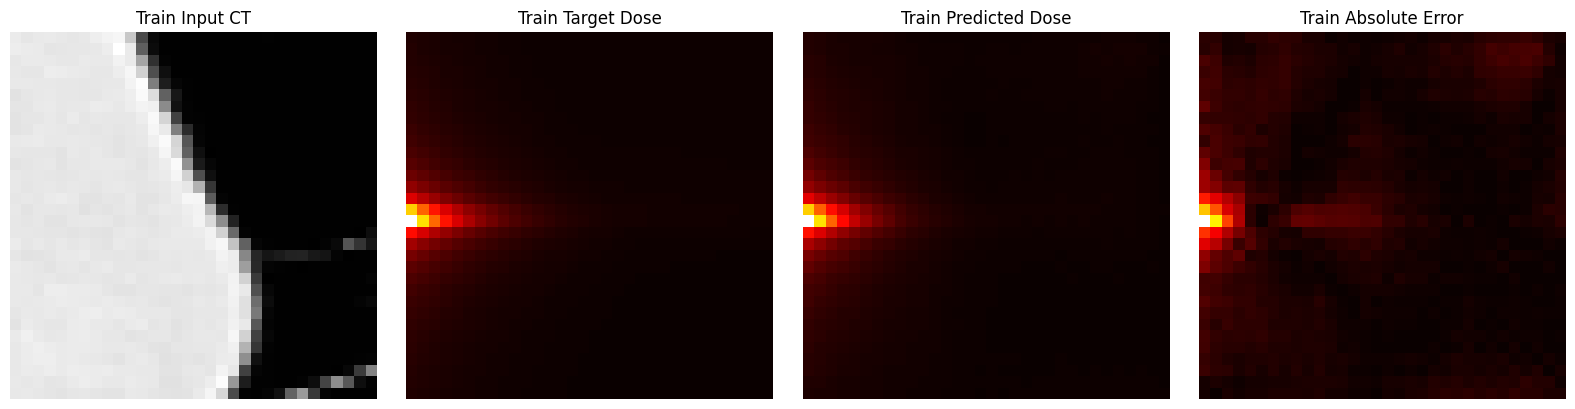

In [84]:
with torch.no_grad():
    x0, x1 = reg_train_subset[0]
    x0 = x0.unsqueeze(0).to(device)   # (1,1,32,32)
    x1 = x1.unsqueeze(0).to(device)

    pred = reg_model(x0)

x0_np = x0[0, 0].cpu().numpy()
x1_np = x1[0, 0].cpu().numpy()
pred_np = pred[0, 0].cpu().numpy()

save_prediction_panel(
    x0_np, x1_np, pred_np,
    FIG_ROOT / "regression_128" / "train_examples.png",
    prefix="Train "
)

### (7)Reconstruct Regression Test Plots

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/regression_128/test_examples.png


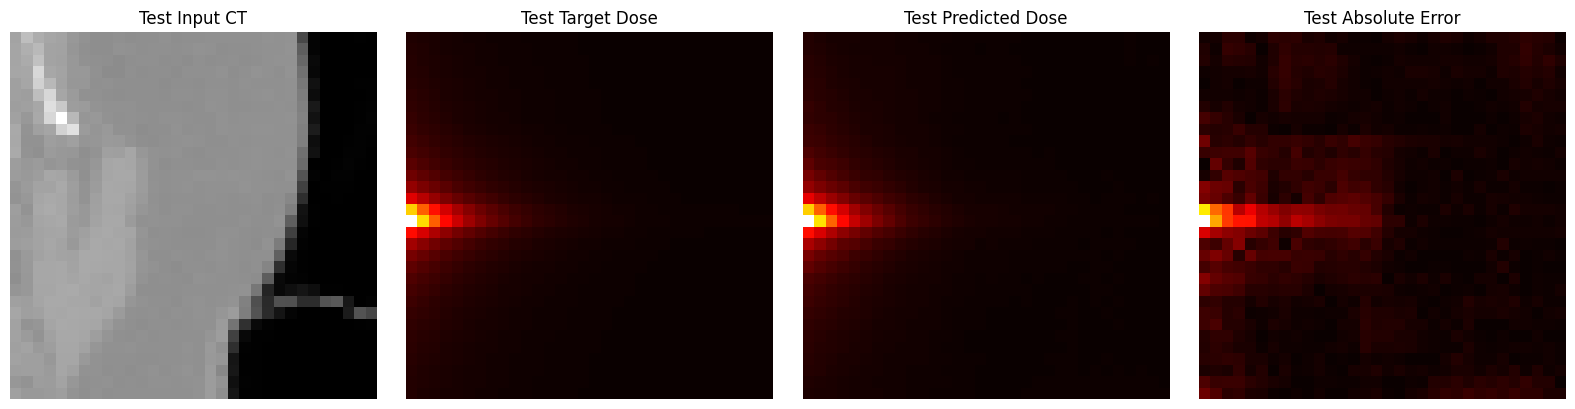

In [85]:
with torch.no_grad():
    x0, x1 = reg_test_subset[0]
    x0 = x0.unsqueeze(0).to(device)
    x1 = x1.unsqueeze(0).to(device)

    pred = reg_model(x0)

x0_np = x0[0, 0].cpu().numpy()
x1_np = x1[0, 0].cpu().numpy()
pred_np = pred[0, 0].cpu().numpy()

save_prediction_panel(
    x0_np, x1_np, pred_np,
    FIG_ROOT / "regression_128" / "test_examples.png",
    prefix="Test "
)

### (8)Load Flow Checkpoints

In [86]:
flow_ckpt_path = Path("/content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/conditional_unet_flow_2d_128samples.pt")
print("exists:", flow_ckpt_path.exists())

flow_ckpt = torch.load(flow_ckpt_path, map_location=device)

flow_model = ConditionalUNetFlow2D(in_ch=3, out_ch=1, base_ch=32).to(device)
flow_model.load_state_dict(flow_ckpt["model_state_dict"])
flow_model.eval()

print(flow_ckpt.keys())

exists: True
dict_keys(['model_state_dict', 'optimizer_state_dict', 'train_losses', 'train_metrics', 'test_metrics', 'dose_scale', 'num_epochs', 'num_train_samples', 'num_test_samples'])


### (9)Reconstruct Flow Loss Curves

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/flow_unet_128/loss_curve.png


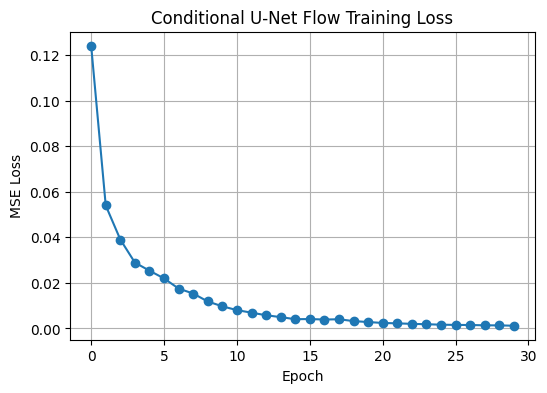

In [87]:
save_loss_curve(
    flow_ckpt["train_losses"],
    title="Conditional U-Net Flow Training Loss",
    save_path=FIG_ROOT / "flow_unet_128" / "loss_curve.png"
)

### (10)Define Euler Sampling Functions

In [88]:
@torch.no_grad()
def euler_sample(model, x0, n_steps=50):
    model.eval()
    z = x0.clone()
    dt = 1.0 / n_steps

    for k in range(n_steps):
        t = torch.full((z.shape[0], 1, 1, 1), k / n_steps, device=z.device)
        v = model(z, x0, t)
        z = z + dt * v

    return z

### (11)Reconstruct Flow Training Plots

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/flow_unet_128/train_examples.png


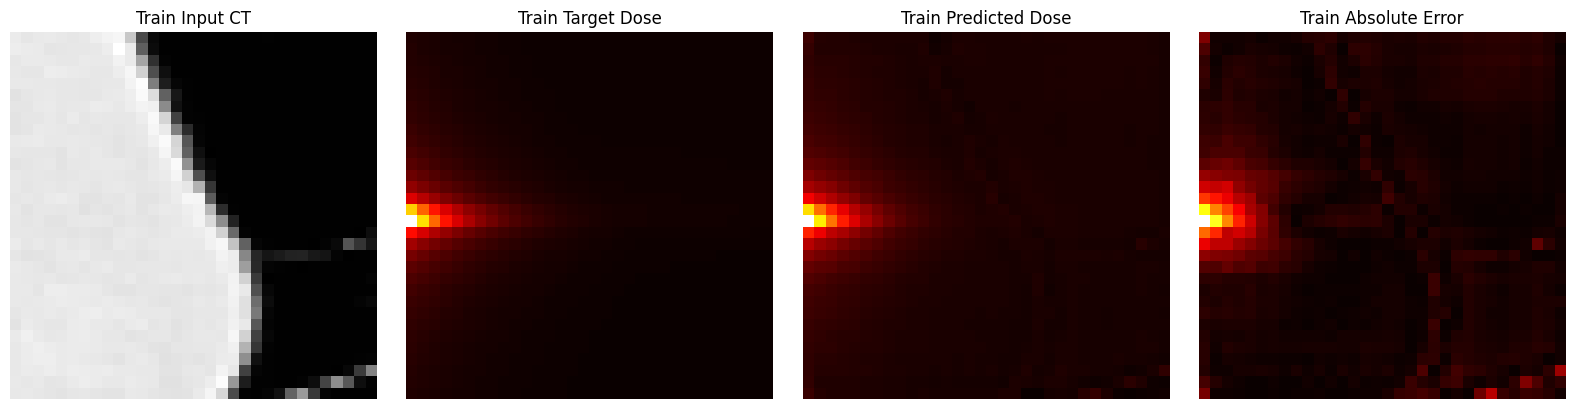

In [89]:
with torch.no_grad():
    x0, x1 = reg_train_subset[0]
    x0 = x0.unsqueeze(0).to(device)
    x1 = x1.unsqueeze(0).to(device)

    pred = euler_sample(flow_model, x0, n_steps=50)

x0_np = x0[0, 0].cpu().numpy()
x1_np = x1[0, 0].cpu().numpy()
pred_np = pred[0, 0].cpu().numpy()

save_prediction_panel(
    x0_np, x1_np, pred_np,
    FIG_ROOT / "flow_unet_128" / "train_examples.png",
    prefix="Train "
)

### (12)Reconstruct Flow Test Plots

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/flow_unet_128/test_examples.png


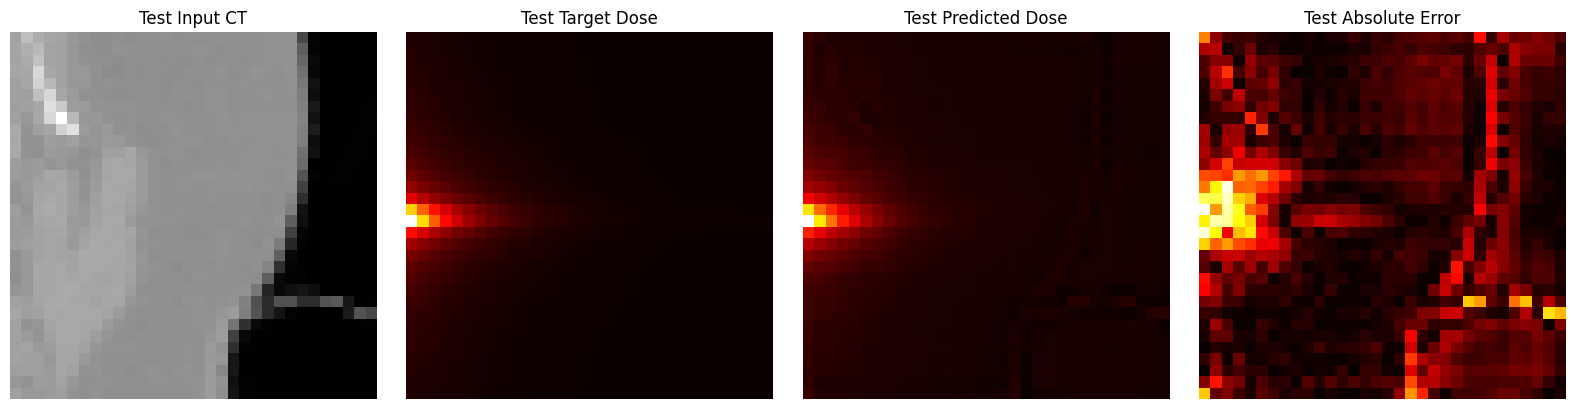

In [90]:
with torch.no_grad():
    x0, x1 = reg_test_subset[0]
    x0 = x0.unsqueeze(0).to(device)
    x1 = x1.unsqueeze(0).to(device)

    pred = euler_sample(flow_model, x0, n_steps=50)

x0_np = x0[0, 0].cpu().numpy()
x1_np = x1[0, 0].cpu().numpy()
pred_np = pred[0, 0].cpu().numpy()

save_prediction_panel(
    x0_np, x1_np, pred_np,
    FIG_ROOT / "flow_unet_128" / "test_examples.png",
    prefix="Test "
)

### (13)Prepare Data and Directories

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

train_manifest = Path("/content/drive/MyDrive/rectified_flow_ct2dose/data/splits/train_pairs_2d.json")
test_manifest  = Path("/content/drive/MyDrive/rectified_flow_ct2dose/data/splits/test_pairs_2d.json")

train_dataset = CubeSlice2DDataset(train_manifest, dose_scale=1000.0)
test_dataset  = CubeSlice2DDataset(test_manifest, dose_scale=1000.0)

FIG_ROOT = Path("/content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures")
for sub in ["regression_small", "regression_128", "flow_small_cnn", "flow_unet_128"]:
    (FIG_ROOT / sub).mkdir(parents=True, exist_ok=True)

CKPT_DIR = Path("/content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints")
print("FIG_ROOT:", FIG_ROOT)
print("CKPT_DIR exists:", CKPT_DIR.exists())

device: cuda
FIG_ROOT: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures
CKPT_DIR exists: True


### (14)Generic Save Function

In [8]:
def save_fig(fig, save_path):
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print("Saved:", save_path)


def save_loss_curve(train_losses, title, save_path):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(train_losses, marker="o")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.grid(True)
    save_fig(fig, save_path)
    plt.show()


def save_prediction_panel(x0_np, x1_np, pred_np, save_path, prefix=""):
    err_np = np.abs(pred_np - x1_np)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(x0_np, cmap="gray")
    axes[0].set_title(f"{prefix}Input CT")
    axes[0].axis("off")

    axes[1].imshow(x1_np, cmap="hot")
    axes[1].set_title(f"{prefix}Target Dose")
    axes[1].axis("off")

    axes[2].imshow(pred_np, cmap="hot")
    axes[2].set_title(f"{prefix}Predicted Dose")
    axes[2].axis("off")

    axes[3].imshow(err_np, cmap="hot")
    axes[3].set_title(f"{prefix}Absolute Error")
    axes[3].axis("off")

    plt.tight_layout()
    save_fig(fig, save_path)
    plt.show()

### (15)Sampling Function (for Flow)

In [9]:
@torch.no_grad()
def euler_sample_simple_flow(model, x0, n_steps=20):
    model.eval()
    z = x0.clone()
    dt = 1.0 / n_steps

    for k in range(n_steps):
        t = torch.full((z.shape[0], 1, 1, 1), k / n_steps, device=z.device)
        v = model(z, t)
        z = z + dt * v

    return z


@torch.no_grad()
def euler_sample_conditional_flow(model, x0, n_steps=50):
    model.eval()
    z = x0.clone()
    dt = 1.0 / n_steps

    for k in range(n_steps):
        t = torch.full((z.shape[0], 1, 1, 1), k / n_steps, device=z.device)
        v = model(z, x0, t)
        z = z + dt * v

    return z

### (16)Reconstruct regression_small Plots (32-sample)

reg_small exists: True
Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/regression_small/loss_curve.png


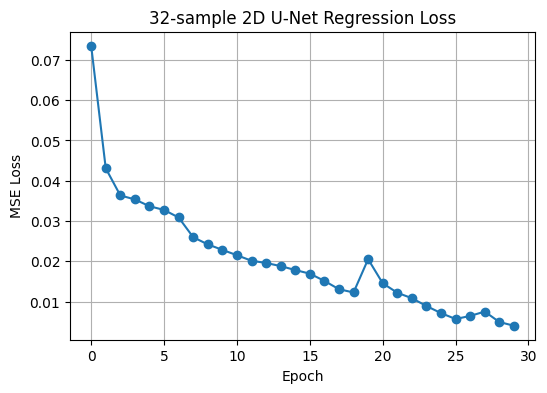

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/regression_small/train_examples.png


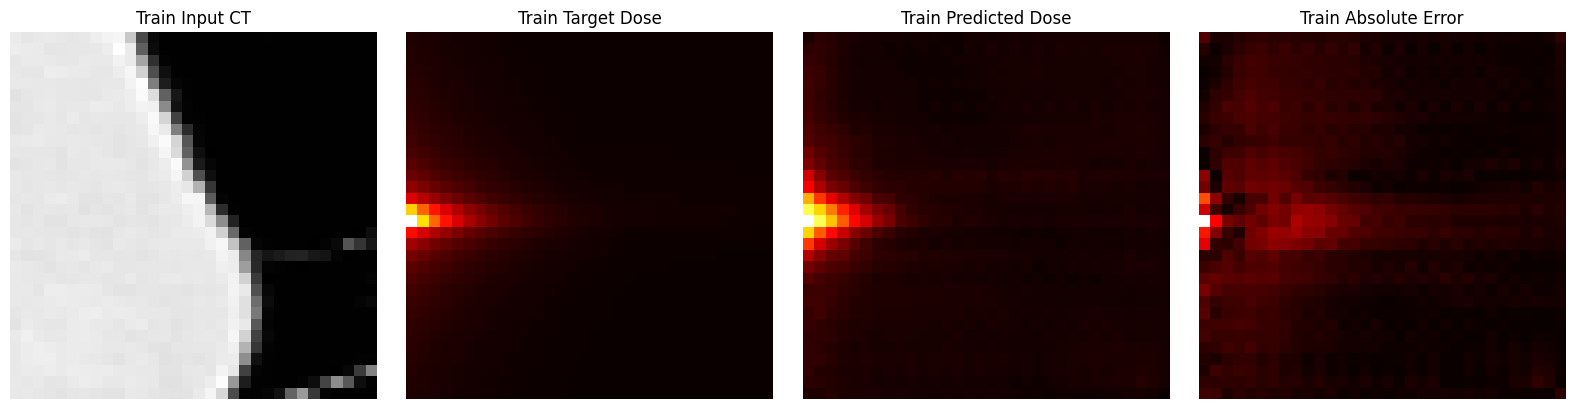

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/regression_small/test_examples.png


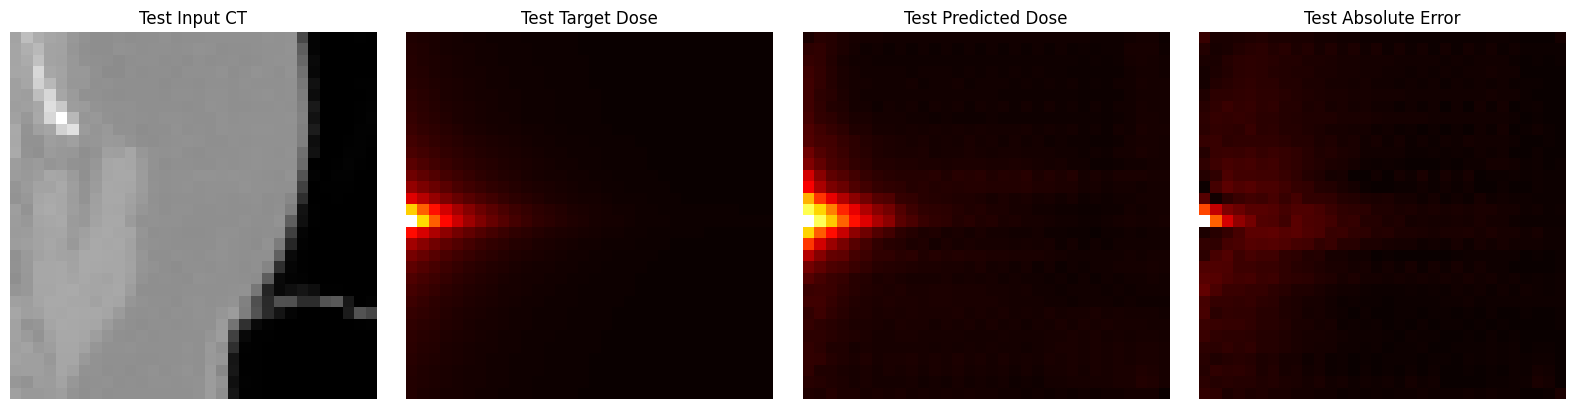

In [10]:
reg_small_ckpt = CKPT_DIR / "unet2d_regression_small.pt"
print("reg_small exists:", reg_small_ckpt.exists())

if reg_small_ckpt.exists():
    ckpt = torch.load(reg_small_ckpt, map_location=device)

    model = UNet2D(in_ch=1, out_ch=1, base_ch=32).to(device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    save_loss_curve(
        ckpt["train_losses"],
        "32-sample 2D U-Net Regression Loss",
        FIG_ROOT / "regression_small" / "loss_curve.png"
    )

    train_subset = Subset(train_dataset, list(range(32)))
    test_subset  = Subset(test_dataset, list(range(16)))

    with torch.no_grad():
        x0, x1 = train_subset[0]
        x0 = x0.unsqueeze(0).to(device)
        x1 = x1.unsqueeze(0).to(device)
        pred = model(x0)

    save_prediction_panel(
        x0[0,0].cpu().numpy(),
        x1[0,0].cpu().numpy(),
        pred[0,0].cpu().numpy(),
        FIG_ROOT / "regression_small" / "train_examples.png",
        prefix="Train "
    )

    with torch.no_grad():
        x0, x1 = test_subset[0]
        x0 = x0.unsqueeze(0).to(device)
        x1 = x1.unsqueeze(0).to(device)
        pred = model(x0)

    save_prediction_panel(
        x0[0,0].cpu().numpy(),
        x1[0,0].cpu().numpy(),
        pred[0,0].cpu().numpy(),
        FIG_ROOT / "regression_small" / "test_examples.png",
        prefix="Test "
    )

### (17)Reconstruct flow_small_cnn Plots (small conditional CNN flow)

flow_small exists: True
Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/flow_small_cnn/loss_curve.png


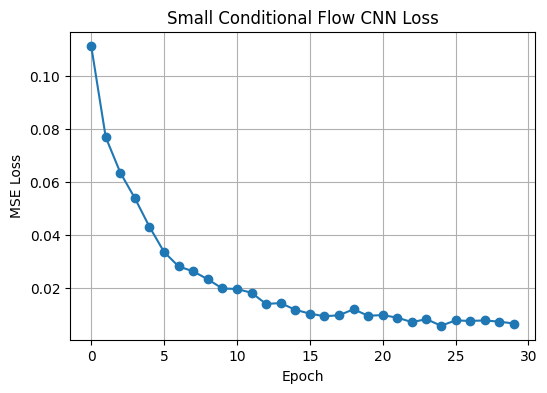

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/flow_small_cnn/train_examples.png


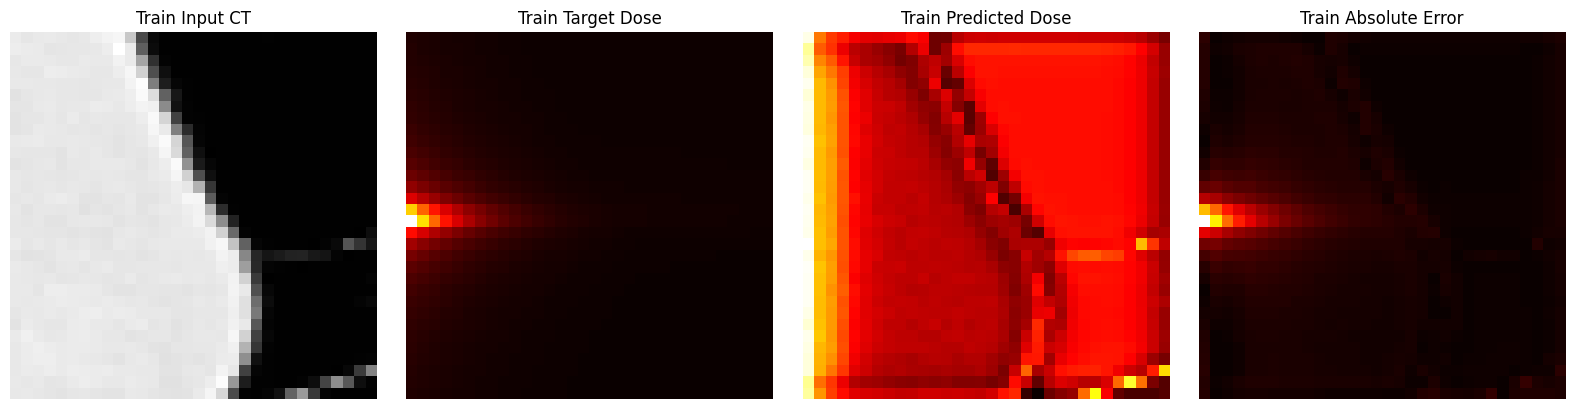

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/flow_small_cnn/test_examples.png


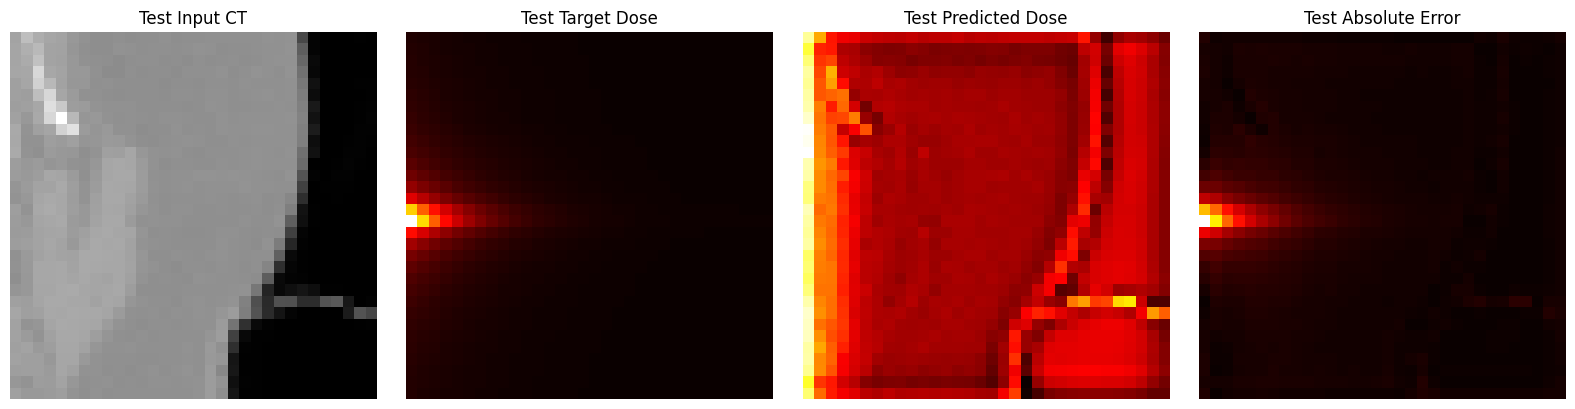

In [15]:
flow_small_ckpt = CKPT_DIR / "conditional_rf_2d_small.pt"
print("flow_small exists:", flow_small_ckpt.exists())

if flow_small_ckpt.exists():
    ckpt = torch.load(flow_small_ckpt, map_location=device)

    model = ConditionalFlowCNN2D(in_channels=3, hidden=32).to(device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    save_loss_curve(
        ckpt["train_losses"],
        "Small Conditional Flow CNN Loss",
        FIG_ROOT / "flow_small_cnn" / "loss_curve.png"
    )

    train_subset = Subset(train_dataset, list(range(32)))
    test_subset  = Subset(test_dataset, list(range(16)))

    with torch.no_grad():
        x0, x1 = train_subset[0]
        x0 = x0.unsqueeze(0).to(device)
        x1 = x1.unsqueeze(0).to(device)
        pred = euler_sample_conditional_flow(model, x0, n_steps=50)

    save_prediction_panel(
        x0[0,0].cpu().numpy(),
        x1[0,0].cpu().numpy(),
        pred[0,0].cpu().numpy(),
        FIG_ROOT / "flow_small_cnn" / "train_examples.png",
        prefix="Train "
    )

    with torch.no_grad():
        x0, x1 = test_subset[0]
        x0 = x0.unsqueeze(0).to(device)
        x1 = x1.unsqueeze(0).to(device)
        pred = euler_sample_conditional_flow(model, x0, n_steps=50)

    save_prediction_panel(
        x0[0,0].cpu().numpy(),
        x1[0,0].cpu().numpy(),
        pred[0,0].cpu().numpy(),
        FIG_ROOT / "flow_small_cnn" / "test_examples.png",
        prefix="Test "
    )

### (18)Final Check of the Image Directory

In [16]:
for folder in ["regression_small", "regression_128", "flow_small_cnn", "flow_unet_128"]:
    p = FIG_ROOT / folder
    print(f"\n{folder}:")
    for f in sorted(p.glob("*.png")):
        print(" -", f.name)


regression_small:
 - loss_curve.png
 - test_examples.png
 - train_examples.png

regression_128:
 - loss_curve.png
 - test_examples.png
 - train_examples.png

flow_small_cnn:
 - loss_curve.png
 - test_examples.png
 - train_examples.png

flow_unet_128:
 - loss_curve.png
 - test_examples.png
 - train_examples.png
